# Clickbait and Emotional Framing: An Analysis of YouTube News Channels


In [2]:
# Mount drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!pip install emoji
!pip install gensim
!pip install vaderSentiment
!pip install NRCLex

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 54.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 3.6 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of nrclex to determine which version is compatible with other requirements. This could take a while.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 396.4/396.4 kB 2.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for NRCLex: filename=NRCLex-3.0.0-py3-none-any.whl size=43309 sha256=ca73aa4bc4c3cd7a6dd5d98aafdbaac015d033e64155d9b96ea2e5ebb3df3bb3
  Stored in directory: /root/.cache/pip/wheels/1f/e8/d0/e3c3da0ef3b37ef4381dbf5c9401f3a9861a63ce221b13d8bb
Successfully built NRCLex


In [16]:
# Imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import re
import nltk
import spacy
from nltk.corpus import stopwords
from wordcloud import WordCloud
import emoji
import tqdm
from spacy.lang.en import English
from joblib import Parallel, delayed
import time
from collections import Counter
from gensim import corpora, models
from nrclex import NRCLex
import networkx as nx

## Exploratory Analysis


In [4]:
# Load first dataset: video + comments info
content_df = pd.read_csv("/content/drive/MyDrive/ANNO2/PRIMO PERIODO 2/SOCIAL MEDIA/PROJECT/content_df.csv")
print('Content:', content_df.shape)

Content: (451047, 10)


In [ ]:
# Dataset snippet
content_df

,channel,video_id,video_timestamp,title,description,comment_id,comment_author,comment_text,comment_likes,comment_timestamp
0,BBC News,JiUoqt4cMrU,2026-01-22 19:30:08+00:00,Ukraine President Zelensky criticises Europe f...,"In a speech to world leaders, Ukraine Presiden...",Ugy_8l4e89Y4_R0cHcZ4AaABAg,@clive5788,The sniffed up grifter is illegitimate anyhoo,0.0,2026-01-22 20:54:04+00:00
1,BBC News,JiUoqt4cMrU,2026-01-22 19:30:08+00:00,Ukraine President Zelensky criticises Europe f...,"In a speech to world leaders, Ukraine Presiden...",UgyoO-LrLTC_3foFPLB4AaABAg,@craigsmith6512,I think the situation on the front is not good...,0.0,2026-01-22 20:50:22+00:00
2,BBC News,JiUoqt4cMrU,2026-01-22 19:30:08+00:00,Ukraine President Zelensky criticises Europe f...,"In a speech to world leaders, Ukraine Presiden...",UgxHbp2nxnaZzcC_1vJ4AaABAg,@MarkKerrigan-o2v,Millions of pounds given to this country,1.0,2026-01-22 20:50:11+00:00
3,BBC News,JiUoqt4cMrU,2026-01-22 19:30:08+00:00,Ukraine President Zelensky criticises Europe f...,"In a speech to world leaders, Ukraine Presiden...",UgyOHGcFGVVkOLcaqLh4AaABAg,@johancruijff4117,A mean junky,1.0,2026-01-22 20:49:31+00:00
4,BBC News,JiUoqt4cMrU,2026-01-22 19:30:08+00:00,Ukraine President Zelensky criticises Europe f...,"In a speech to world leaders, Ukraine Presiden...",Ugyi9bYFVUpVZWw4pRF4AaABAg,@jamesgreen1116,Nato created a monster which will eventually t...,0.0,2026-01-22 20:49:11+00:00
...,...,...,...,...,...,...,...,...,...,...
451042,The Jimmy Dore Show,h2iP8YdXfds,2025-10-29 18:00:30+00:00,Meet The AIPAC-Funded GOP Candidate Vying To B...,President Donald Trump and AIPAC are backing c...,UgzdH0awHHzWsk4y1w14AaABAg,@backandtotheleft,ed gallrein - woodshed vibes,0.0,2025-10-30 11:35:59+00:00
451043,The Jimmy Dore Show,h2iP8YdXfds,2025-10-29 18:00:30+00:00,Meet The AIPAC-Funded GOP Candidate Vying To B...,President Donald Trump and AIPAC are backing c...,UgxJZ_zl8f5c5xivkGp4AaABAg,@mmjnr10,I'm worried about Massie's life at this point ...,1.0,2025-10-30 11:24:32+00:00
451044,The Jimmy Dore Show,h2iP8YdXfds,2025-10-29 18:00:30+00:00,Meet The AIPAC-Funded GOP Candidate Vying To B...,President Donald Trump and AIPAC are backing c...,UgxsUUpc3sHmEYUS2114AaABAg,@williamthomas5215,"AIPAC, Zionist, globalist? Just say jew",0.0,2025-10-30 11:17:01+00:00
451045,The Jimmy Dore Show,h2iP8YdXfds,2025-10-29 18:00:30+00:00,Meet The AIPAC-Funded GOP Candidate Vying To B...,President Donald Trump and AIPAC are backing c...,Ugy6_nn_F_rirxOECCp4AaABAg,@ludivinabentadan1243,Thomas Massie for President and MTG for Vice P...,1.0,2025-10-30 11:12:27+00:00


In [5]:
# Check for missing values
print('Missing Values:\n', content_df.isna().sum())
# Check for duplicates
print("\nDuplicates:", content_df.duplicated().sum())

Missing Values:
 channel               0
video_id              0
video_timestamp       0
title                 0
description          40
comment_id            0
comment_author        8
comment_text         47
comment_likes         0
comment_timestamp     0
dtype: int64

Duplicates: 71


In [6]:
# Check NAs in videos description: 40 obervations were imputed empty string in description variable
print(content_df[content_df['description'].isna()])
content_df['description'] = content_df['description'].fillna('')

       channel     video_id            video_timestamp  \
171553     CNN  qisK4Yag42o  2025-12-05 21:03:13+00:00   
171554     CNN  qisK4Yag42o  2025-12-05 21:03:13+00:00   
171555     CNN  qisK4Yag42o  2025-12-05 21:03:13+00:00   
171556     CNN  qisK4Yag42o  2025-12-05 21:03:13+00:00   
171557     CNN  qisK4Yag42o  2025-12-05 21:03:13+00:00   
171558     CNN  qisK4Yag42o  2025-12-05 21:03:13+00:00   
171559     CNN  qisK4Yag42o  2025-12-05 21:03:13+00:00   
171560     CNN  qisK4Yag42o  2025-12-05 21:03:13+00:00   
171561     CNN  qisK4Yag42o  2025-12-05 21:03:13+00:00   
171562     CNN  qisK4Yag42o  2025-12-05 21:03:13+00:00   
171563     CNN  qisK4Yag42o  2025-12-05 21:03:13+00:00   
171564     CNN  qisK4Yag42o  2025-12-05 21:03:13+00:00   
171565     CNN  qisK4Yag42o  2025-12-05 21:03:13+00:00   
171566     CNN  qisK4Yag42o  2025-12-05 21:03:13+00:00   
171567     CNN  qisK4Yag42o  2025-12-05 21:03:13+00:00   
171568     CNN  qisK4Yag42o  2025-12-05 21:03:13+00:00   
171569     CNN

In [7]:
# Check NAs in comments text; Removed 47 observations;
print(content_df[content_df['comment_text'].isna()])
content_df = content_df.dropna(subset=['comment_text'])

                    channel     video_id            video_timestamp  \
916                BBC News  BY11cl7ZrC0  2026-01-21 23:02:37+00:00   
3950               BBC News  1V6BGv7uH5E  2026-01-20 11:30:13+00:00   
16335              BBC News  askp779pPnQ  2026-01-11 08:45:25+00:00   
16337              BBC News  askp779pPnQ  2026-01-11 08:45:25+00:00   
16796              BBC News  bcOfsg749Wk  2026-01-09 22:12:38+00:00   
29235              BBC News  7XaCK9VqFE8  2025-12-31 10:25:35+00:00   
30223              BBC News  86-FqCIwjsA  2025-12-29 19:30:01+00:00   
30709              BBC News  qOT_H4jORAk  2025-12-28 23:38:23+00:00   
31977              BBC News  B4m31m-G0Jc  2025-12-26 17:00:15+00:00   
47343              BBC News  _GFv73bvxtI  2025-12-09 17:37:56+00:00   
57830              BBC News  s9PrcGxS-UA  2025-11-30 17:01:32+00:00   
83744              BBC News  cL98lYPS8B4  2025-11-10 05:39:57+00:00   
83801              BBC News  cL98lYPS8B4  2025-11-10 05:39:57+00:00   
85105 

In [8]:
# Check NAs in comment author: 8 obervations were removed;
print(content_df[content_df['comment_author'].isna()])
content_df = content_df.dropna(subset=['comment_author'])

                    channel     video_id            video_timestamp  \
172207                  CNN  oKy0eWPxqZo  2025-12-05 17:27:36+00:00   
266297                  CNN  5nhs-wlffe4  2025-10-28 18:35:38+00:00   
302010      The Young Turks  Tt1raC3AhtE  2025-12-31 03:00:41+00:00   
345713      The Young Turks  4fzo_geRTwo  2025-11-22 05:15:00+00:00   
348176      The Young Turks  reHD6rj-4y4  2025-11-20 04:30:39+00:00   
409270  The Jimmy Dore Show  zraiQeR1p0o  2025-12-17 21:05:44+00:00   
423252  The Jimmy Dore Show  lpLrylvnVlA  2025-12-03 19:05:58+00:00   
426637  The Jimmy Dore Show  wSxqZfhFfIQ  2025-11-27 02:34:32+00:00   

                                                    title  \
172207  Doctor's advice to parents: Don't listen to th...   
266297  Netanyahu orders ‘immediate, powerful’ strikes...   
302010             Alan Dershowitz Has Lost His Damn Mind   
345713  Thomas Massie Says Epstein Had Ties To Israeli...   
348176  Cenk and "America First" Veteran Unify... And .

In [9]:
# Check for Duplicates; We safely remove 71 observations: just errors;
print(content_df[content_df.duplicated()])
content_df = content_df.drop_duplicates(subset=['comment_id'])

                    channel     video_id            video_timestamp  \
168113                  CNN  cKlI4gz5Tgk  2025-12-07 14:01:07+00:00   
274493      The Young Turks  5j5EhBcnbBA  2026-01-21 04:30:00+00:00   
283299      The Young Turks  bdqUBrL3kJk  2026-01-15 04:30:20+00:00   
283504      The Young Turks  fS-lHlD9vmI  2026-01-15 03:45:04+00:00   
284490      The Young Turks  MMEO9XZ3VMo  2026-01-14 05:15:02+00:00   
...                     ...          ...                        ...   
401247  The Jimmy Dore Show  ksnX9ZDIZ4M  2025-12-25 20:27:12+00:00   
412490  The Jimmy Dore Show  vKTyg89XTD8  2025-12-14 22:35:06+00:00   
417144  The Jimmy Dore Show  smBQreaCtY4  2025-12-10 20:09:21+00:00   
445451  The Jimmy Dore Show  i6XWj2ynGBs  2025-11-05 18:26:29+00:00   
450954  The Jimmy Dore Show  h2iP8YdXfds  2025-10-29 18:00:30+00:00   

                                                    title  \
168113  Jonathan Bailey & David Corenswet | Off the Se...   
274493  You Won't BELIEVE

In [10]:
# Check for missing values
print('Missing Values:\n', content_df.isna().sum())
# Check for duplicates
print("\nDuplicates:", content_df.duplicated().sum())

Missing Values:
 channel              0
video_id             0
video_timestamp      0
title                0
description          0
comment_id           0
comment_author       0
comment_text         0
comment_likes        0
comment_timestamp    0
dtype: int64

Duplicates: 0


In [11]:
# Check: how many single videos were left after merging?
content_df['video_id'].nunique()

2608

In [12]:
# Check: what is the minimum number of comments per video?
print(content_df.groupby('video_id').size().min())

3


In [13]:
# Check: what is the max number of comments per video?
print(content_df.groupby('video_id').size().max())

299


In [15]:
content_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 450921 entries, 0 to 451046
Data columns (total 10 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   channel            450921 non-null  object 
 1   video_id           450921 non-null  object 
 2   video_timestamp    450921 non-null  object 
 3   title              450921 non-null  object 
 4   description        450921 non-null  object 
 5   comment_id         450921 non-null  object 
 6   comment_author     450921 non-null  object 
 7   comment_text       450921 non-null  object 
 8   comment_likes      450921 non-null  float64
 9   comment_timestamp  450921 non-null  object 
dtypes: float64(1), object(9)
memory usage: 37.8+ MB


In [16]:
# Exploratory summary of the dataset
video_counts = content_df.groupby('channel')['video_id'].nunique()
comment_counts = content_df.groupby('channel')['comment_id'].count()

summary_table = pd.DataFrame({
    'Unique Videos': video_counts,
    'Total Comments': comment_counts
}).reset_index()

summary_table

,channel,Unique Videos,Total Comments
0,BBC News,589,92794
1,CNN,1053,179372
2,The Jimmy Dore Show,376,73488
3,The Young Turks,590,105267


In [17]:
# Percentage of total comments by channel; Distribution of comment likes (across the dataset)
print(content_df['channel'].value_counts(normalize=True))  # % by channel
print(content_df.describe())  # comment likes

channel
CNN                    0.397790
The Young Turks        0.233449
BBC News               0.205788
The Jimmy Dore Show    0.162973
Name: proportion, dtype: float64
       comment_likes
count  450921.000000
mean        1.499646
std        10.137326
min         0.000000
25%         0.000000
50%         0.000000
75%         1.000000
max      3977.000000


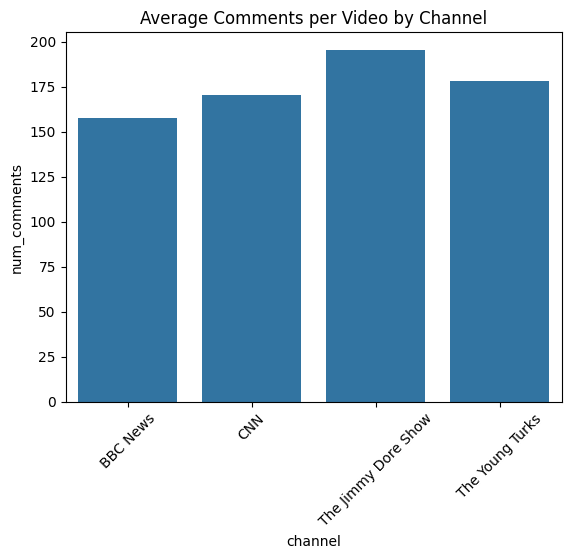

In [18]:
# Acerage comments per video per channel
comments_per_video = content_df.groupby(['channel', 'video_id']).size().reset_index(name='num_comments')
avg_comments = comments_per_video.groupby('channel')['num_comments'].mean().reset_index()

sns.barplot(data=avg_comments, x='channel', y='num_comments')
plt.title('Average Comments per Video by Channel')
plt.xticks(rotation=45)
plt.show()


### Temporal Activity (EDA)


In [19]:
# Date transformations
content_df['comment_timestamp'] = pd.to_datetime(content_df['comment_timestamp'], utc=True)
content_df['video_timestamp'] = pd.to_datetime(content_df['video_timestamp'], utc=True)

content_df['comment_month'] = content_df['comment_timestamp'].dt.to_period('M')
content_df['video_month'] = content_df['video_timestamp'].dt.to_period('M')


content_df['comment_date'] = content_df['comment_timestamp'].dt.date
content_df['video_date'] = content_df['video_timestamp'].dt.date

/tmp/ipython-input-58907534.py:5: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  content_df['comment_month'] = content_df['comment_timestamp'].dt.to_period('M')
/tmp/ipython-input-58907534.py:6: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  content_df['video_month'] = content_df['video_timestamp'].dt.to_period('M')


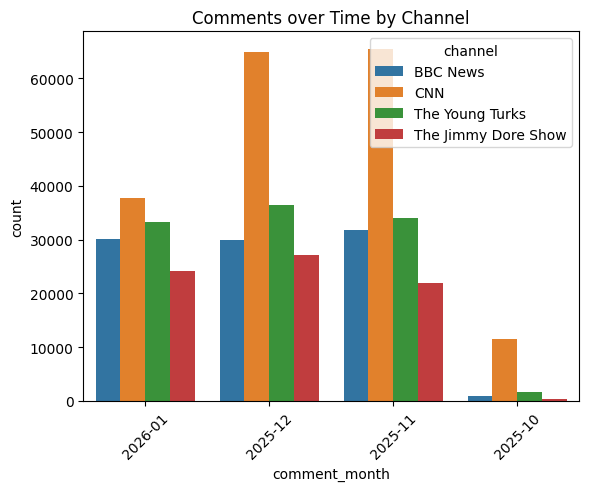

In [20]:
# Monthly comments by channel
sns.countplot(data=content_df, x='comment_month', hue='channel')
plt.title('Comments over Time by Channel')
plt.xticks(rotation=45)
plt.show()

How does audience activity evolve over time across channels?

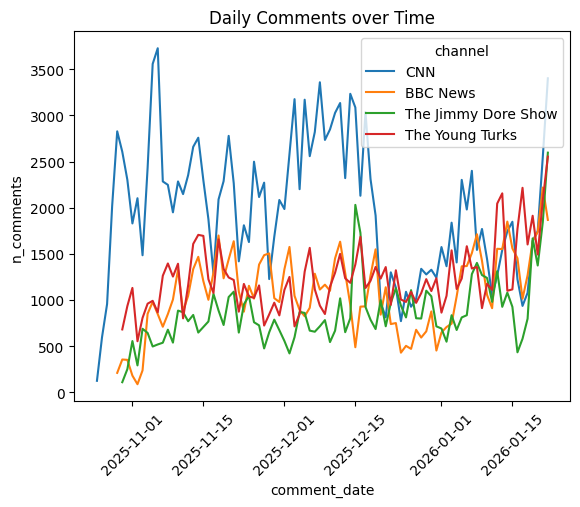

In [21]:
# Daily comment by channel
daily_comments = content_df.groupby(['comment_date','channel']).size().reset_index(name='n_comments')

sns.lineplot(data=daily_comments, x='comment_date', y='n_comments', hue='channel')
plt.title('Daily Comments over Time')
plt.xticks(rotation=45)
plt.show()


/tmp/ipython-input-4048906368.py:4: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  videos_time['video_month'] = videos_time['video_timestamp'].dt.to_period('M')


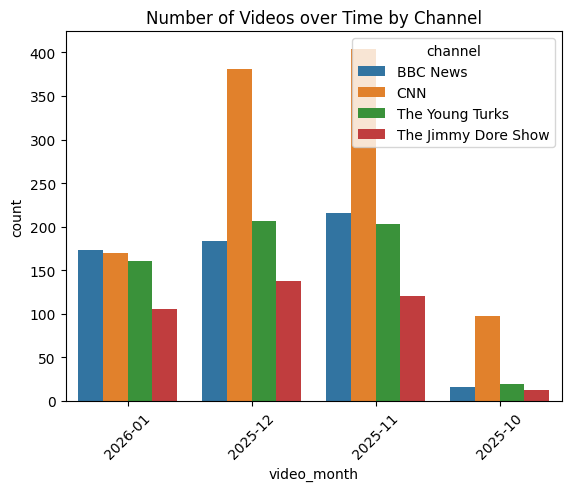

In [22]:
# Monthly videos by channel

videos_time = content_df[['video_id','channel','video_timestamp']].drop_duplicates()
videos_time['video_month'] = videos_time['video_timestamp'].dt.to_period('M')

sns.countplot(data=videos_time, x='video_month', hue='channel')
plt.title('Number of Videos over Time by Channel')
plt.xticks(rotation=45)
plt.show()


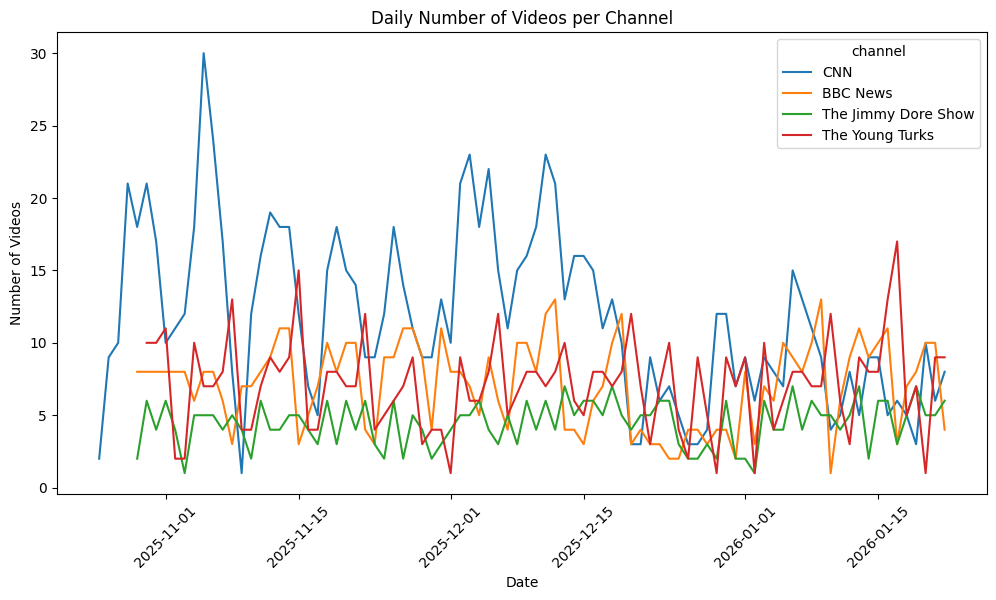

In [23]:
# Daily videos by channel
videos_df = content_df[['video_id', 'channel', 'video_timestamp']].drop_duplicates()
videos_df['video_date'] = videos_df['video_timestamp'].dt.date

daily_videos = videos_df.groupby(['video_date', 'channel']).size().reset_index(name='n_videos')

plt.figure(figsize=(12,6))
sns.lineplot(data=daily_videos, x='video_date', y='n_videos', hue='channel')
plt.title('Daily Number of Videos per Channel')
plt.xlabel('Date')
plt.ylabel('Number of Videos')
plt.xticks(rotation=45)
plt.show()



In [24]:
# top 10 days by total engagement
top_days = (
    content_df
    .groupby('comment_date')
    .size()
    .nlargest(10)
)

top_days


,0
comment_date,
2026-01-22,10422
2026-01-21,8696
2025-12-12,7285
2025-12-15,6991
2026-01-19,6859
2025-11-14,6580
2026-01-07,6529
2025-11-20,6495
2025-12-16,6470


In [26]:
# Filtering by comment dates with highest engagement
top_dates = top_days.index
top_day_comments = content_df[content_df['comment_date'].isin(top_dates)]

# Top commented videos on those days
top_videos_per_day = (
    top_day_comments
    .groupby(['comment_date', 'video_id', 'title', 'channel'])
    .size()
    .reset_index(name='num_comments')
    .sort_values(['comment_date', 'num_comments'], ascending=[True, False])
)


In [27]:
# Top 3 videos per most engaging day
top_videos_daily = top_videos_per_day.groupby('comment_date').head(3)
top_videos_daily


,comment_date,video_id,title,channel,num_comments
155,2025-11-13,YDRSmYlIXvY,House votes to end longest shutdown in US history,CNN,182
65,2025-11-13,DOAWH81BtkY,Trump signs bill to reopen government after lo...,CNN,171
146,2025-11-13,VsZYNzHcrhE,Speaker Johnson says the House will vote next ...,CNN,171
278,2025-11-14,0yt2sMQndys,Trump's Base Is JUMPING SHIP,The Young Turks,182
490,2025-11-14,ilIEDaxTpME,What Did Trump REALLY Know About Epstein?!?,The Young Turks,169
482,2025-11-14,ghnBAljb9_o,Trump Named In Latest Epstein Emails! What you...,The Jimmy Dore Show,163
859,2025-11-20,xw3XtXhACR8,Attendees arrive at Natl Cathedral for former ...,CNN,190
759,2025-11-20,emjET20ZSsQ,Trump signs bill ordering justice department t...,BBC News,182
566,2025-11-20,1FExW2O88Q0,'This has not been a positive for President Tr...,CNN,164
1192,2025-12-12,q3JOOgF1Y14,Senate votes down dueling health care proposals,CNN,179


In [28]:
# Comparison: video production vs comment activity
videos_monthly = videos_time.groupby(['video_month','channel']).size().reset_index(name='n_videos')
comments_monthly = content_df.groupby(['comment_month','channel']).size().reset_index(name='n_comments')


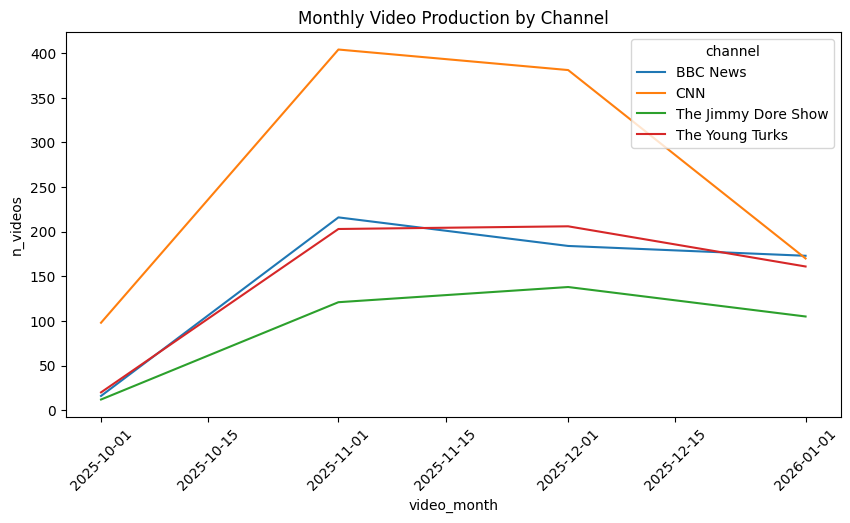

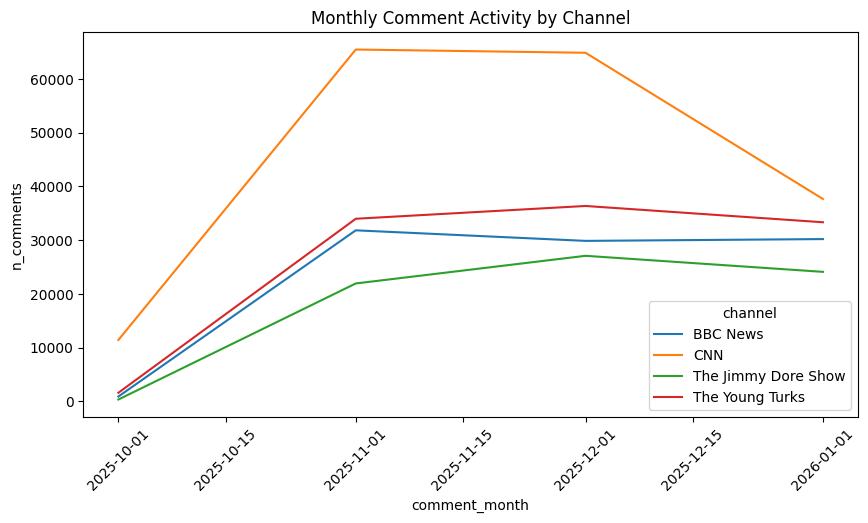

In [29]:
# Number of videos published per channel monthly
plt.figure(figsize=(10,5))
sns.lineplot(data=videos_monthly, x=videos_monthly['video_month'].dt.to_timestamp(), y='n_videos', hue='channel')
plt.title('Monthly Video Production by Channel')
plt.xticks(rotation=45)
plt.show()

# Number of total comment received per channel monthly
plt.figure(figsize=(10,5))
sns.lineplot(data=comments_monthly, x=comments_monthly['comment_month'].dt.to_timestamp(), y='n_comments', hue='channel')
plt.title('Monthly Comment Activity by Channel')
plt.xticks(rotation=45)
plt.show()


Do more videos automatically mean more engagement?
Comparing video production and comment activity reveals whether audience engagement follows content volume or shows disproportionate reactions.

In [31]:
# Number of comment per video + videomonth
comments_per_video_month = (
    content_df
    .groupby(['channel', 'video_month', 'video_id'])
    .size()
    .reset_index(name='num_comments')
)

# Average numeber of comments per video monthly
avg_comments_monthly = (
    comments_per_video_month
    .groupby(['channel', 'video_month'])['num_comments']
    .mean()
    .reset_index()
)

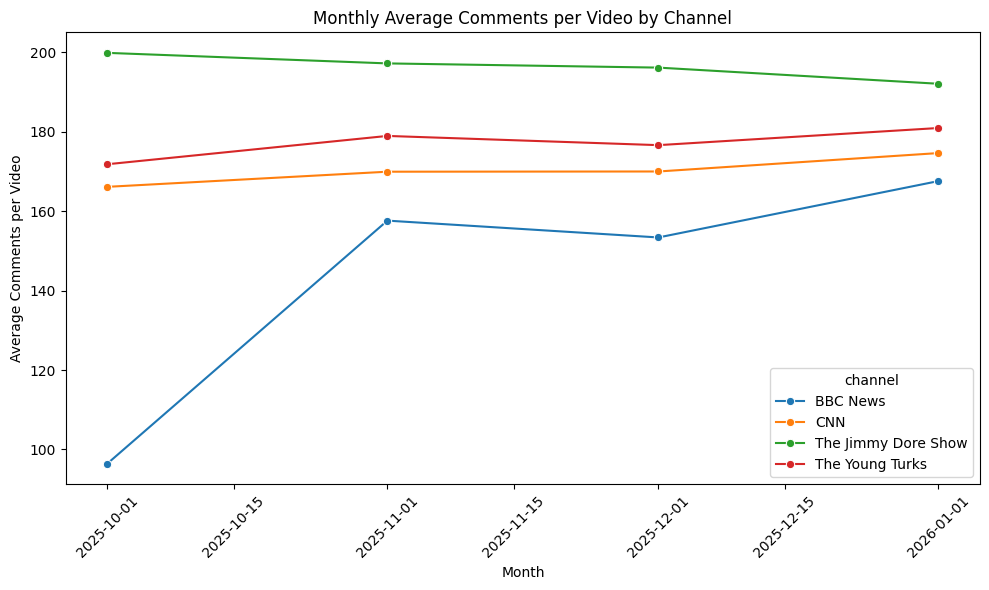

In [33]:
# Average number of comments per video, monthly;
plt.figure(figsize=(10,6))
sns.lineplot(data=avg_comments_monthly, x=avg_comments_monthly['video_month'].dt.to_timestamp(), y='num_comments', hue='channel', marker = 'o')
plt.title('Monthly Average Comments per Video by Channel')
plt.xlabel('Month')
plt.ylabel('Average Comments per Video')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [34]:
# Summary temporal activity
temporal_summary = content_df.groupby('channel').agg(
    first_date=('comment_timestamp','min'),
    last_date=('comment_timestamp','max'),
    total_comments=('comment_id','count'),
    unique_videos=('video_id','nunique')
)
temporal_summary

,first_date,last_date,total_comments,unique_videos
channel,,,,
BBC News,2025-10-29 18:30:52+00:00,2026-01-22 20:54:10+00:00,92794,589
CNN,2025-10-25 21:34:11+00:00,2026-01-22 21:07:34+00:00,179372,1053
The Jimmy Dore Show,2025-10-30 08:57:37+00:00,2026-01-22 21:39:07+00:00,73488,376
The Young Turks,2025-10-30 01:10:58+00:00,2026-01-22 21:26:43+00:00,105267,590


### Engagement Overview

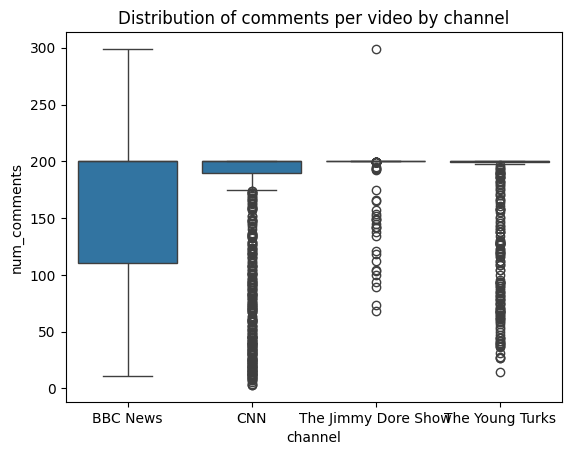

In [35]:
# Comments distribution per video
comments_per_video = (
    content_df
    .groupby(['channel','video_id'])
    .size()
    .reset_index(name='num_comments')
)

sns.boxplot(data=comments_per_video, x='channel', y='num_comments')
plt.title("Distribution of comments per video by channel")
plt.show()


In [36]:
# mean, median and std by channel (comments per video)
comments_stats = (
    comments_per_video
    .groupby('channel')['num_comments']
    .agg(['mean','median','std'])
)

comments_stats

,mean,median,std
channel,,,
BBC News,157.544992,200.0,59.187786
CNN,170.343780,200.0,58.027524
The Jimmy Dore Show,195.446809,200.0,19.819515
The Young Turks,178.418644,200.0,45.257678


In [37]:
# average likes per comment
content_df.groupby('channel')['comment_likes'].mean()

,comment_likes
channel,
BBC News,1.879561
CNN,1.049919
The Jimmy Dore Show,0.936915
The Young Turks,2.323919


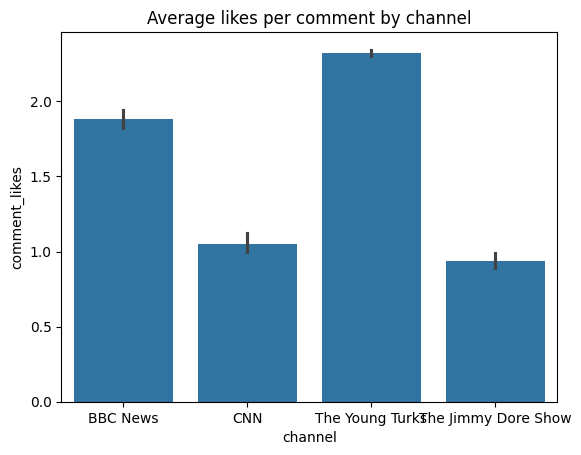

In [38]:
# Average likes per comment by channel
sns.barplot(data=content_df, x='channel', y='comment_likes', estimator='mean')
plt.title("Average likes per comment by channel")
plt.show()


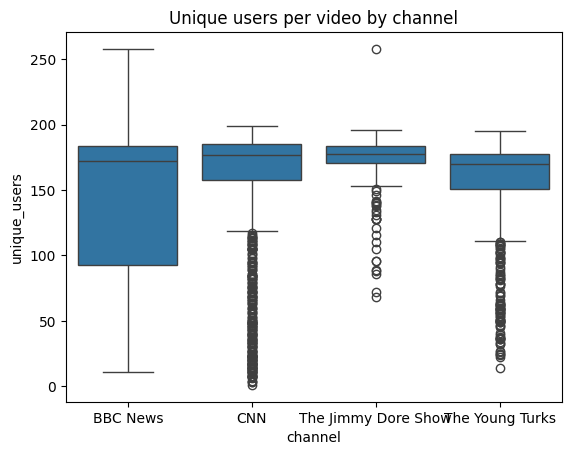

In [39]:
# unique users (as comment authors, replies are not included) per video by channel
users_per_video = (
    content_df
    .groupby(['channel','video_id'])['comment_author']
    .nunique()
    .reset_index(name='unique_users')
)

sns.boxplot(data=users_per_video, x='channel', y='unique_users')
plt.title("Unique users per video by channel")
plt.show()


### Clickbait: Descriptive Indicators

| Dimension      | Example Metric                                                     | Why here                     |
| -------------- | ------------------------------------------------------------------ | ---------------------------- |
| **Lexical**    | presence of clickbait terms (e.g. “shocking”, “you won’t believe”) | linguistic pattern in titles |
| **Structural** | punctuation score, uppercase ratio, title length                   | stylistic markers            |
| **Behavioral** | comments per video, likes per comment                              | engagement behavior          |


Goal of this section: Build simple, interpretable indicators of clickbait and show how they differ across channels and relate to engagement.

Initial operational definition of clickbait based on:
- lexical features
- structural features
- behavioral features
- and to compare these indicators across mainstream and alternative channels.

#### Lexical Features: Clickbait terms

In [42]:
# Proxy: definition of clickbait terms/sentences
clickbait_terms = [
    "shocking","amazing","unbelievable","must see","won’t believe",
    "this is why","reveal","secret","what happens next","they don’t want",
    "pov","of the year", "will change your life", "trick", "can help you","finally",
    "uncovered", "hidden", "the most", "absolutely", "totally", "this changes everything","really", "10 reasons", "top 5"
]


In [43]:
# Lowercase titles
content_df['title_clean'] = content_df['title'].str.lower()

In [44]:
# Flag clickbait titles
pattern = '|'.join(clickbait_terms)
content_df['has_clickbait_terms'] = content_df['title_clean'].str.contains(pattern, regex=True)


In [45]:
# Percentage of clickbait titles per channel
clickbait_ratio = content_df.groupby('channel')['has_clickbait_terms'].mean() * 100
clickbait_ratio


,has_clickbait_terms
channel,
BBC News,1.742570
CNN,1.627344
The Jimmy Dore Show,6.322121
The Young Turks,8.069955


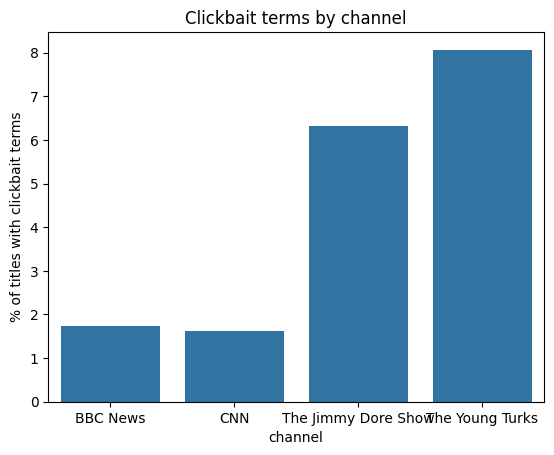

In [46]:
sns.barplot(x=clickbait_ratio.index, y=clickbait_ratio.values)
plt.ylabel("% of titles with clickbait terms")
plt.title("Clickbait terms by channel")
plt.show()


#### Structural Indicators

In [47]:
# Punctuation Score
content_df['punctuation_score'] = content_df['title'].str.count('[!?]')

In [48]:
# Aversage per channel
content_df.groupby('channel')['punctuation_score'].mean()

,punctuation_score
channel,
BBC News,0.177953
CNN,0.038780
The Jimmy Dore Show,1.093675
The Young Turks,0.294109


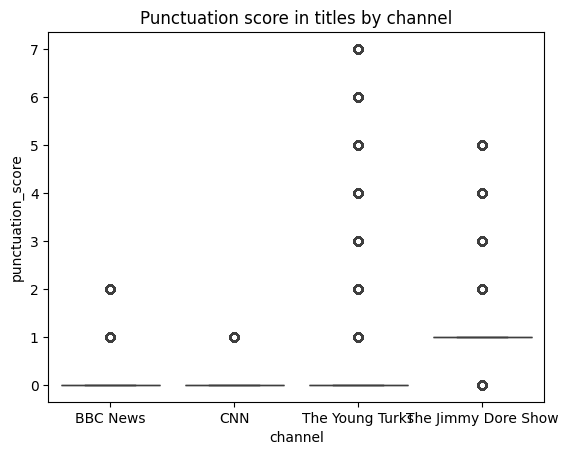

In [49]:
# Distribution punctuation score per channel (titles)
sns.boxplot(data=content_df, x='channel', y='punctuation_score')
plt.title("Punctuation score in titles by channel")
plt.show()


In [50]:
# Uppercase ratio
def uppercase_ratio(text):
    letters = [c for c in text if c.isalpha()]
    if len(letters) == 0:
        return 0
    return sum(1 for c in letters if c.isupper()) / len(letters)

content_df['uppercase_ratio'] = content_df['title'].apply(uppercase_ratio)


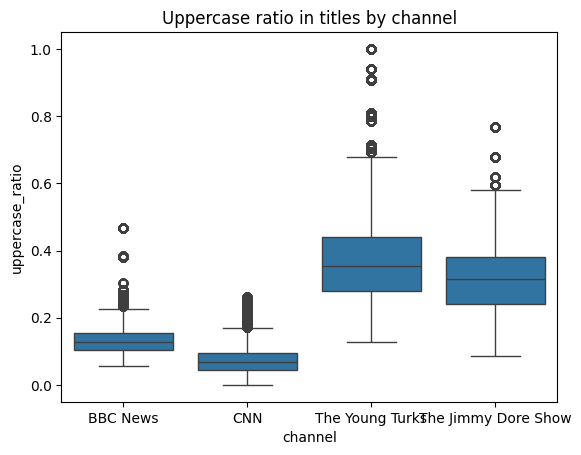

In [51]:
sns.boxplot(data=content_df, x='channel', y='uppercase_ratio')
plt.title("Uppercase ratio in titles by channel")
plt.show()


In [52]:
# Title length: number of words
content_df['title_length'] = content_df['title'].str.split().str.len()

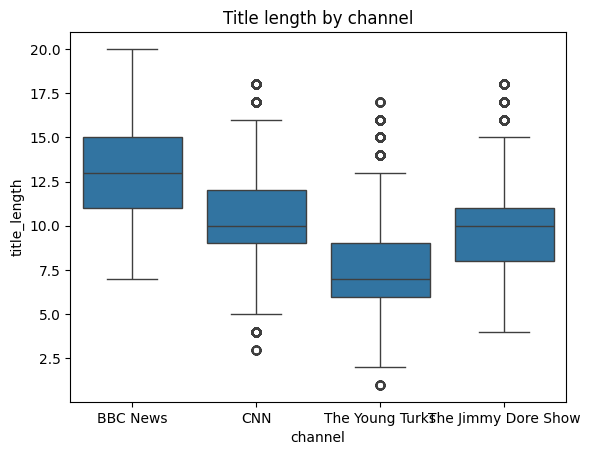

In [53]:
sns.boxplot(data=content_df, x='channel', y='title_length')
plt.title("Title length by channel")
plt.show()


Clickbait titles tend to be shorter.

#### Behavioral Indicators

- correlation between punctuation score and number of comments
- correlation between title lenght and engagement

Our questions is: do clickbait metrics/indicators correlate with more engagement?

In [54]:
# Number of comment per video
comments_per_video = content_df.groupby(['channel','video_id']).size().reset_index(name='num_comments')

In [55]:
# Number of comment per video
comments_per_video

,channel,video_id,num_comments
0,BBC News,-2Tq-leZgs4,112
1,BBC News,-k-kDKPwfqg,11
2,BBC News,-sQSQaUt3SQ,200
3,BBC News,-v1y8fXJyc8,200
4,BBC News,05hu843QRtw,200
...,...,...,...
2603,The Young Turks,zQsMoqFIzCY,197
2604,The Young Turks,zVzjGzBdwbU,200
2605,The Young Turks,z_feI0Irjdc,200
2606,The Young Turks,ztL0IZJHkxE,200


In [56]:
# Merge
video_features = content_df[['video_id','channel','punctuation_score','title_length','uppercase_ratio','has_clickbait_terms']].drop_duplicates()
engagement_df = comments_per_video.merge(video_features, on=['video_id','channel'])


In [57]:
print(engagement_df.shape)
engagement_df.head()


(2608, 7)


,channel,video_id,num_comments,punctuation_score,title_length,uppercase_ratio,has_clickbait_terms
0,BBC News,-2Tq-leZgs4,112,1,10,0.116279,False
1,BBC News,-k-kDKPwfqg,11,0,12,0.092593,False
2,BBC News,-sQSQaUt3SQ,200,0,16,0.171875,False
3,BBC News,-v1y8fXJyc8,200,0,13,0.138889,False
4,BBC News,05hu843QRtw,200,1,15,0.097222,False


In [58]:
# Correlation
engagement_df[['punctuation_score','title_length','uppercase_ratio','num_comments']].corr()

,punctuation_score,title_length,uppercase_ratio,num_comments
punctuation_score,1.000000,-0.047111,0.380170,0.014946
title_length,-0.047111,1.000000,-0.366325,-0.100358
uppercase_ratio,0.380170,-0.366325,1.000000,0.108333
num_comments,0.014946,-0.100358,0.108333,1.000000


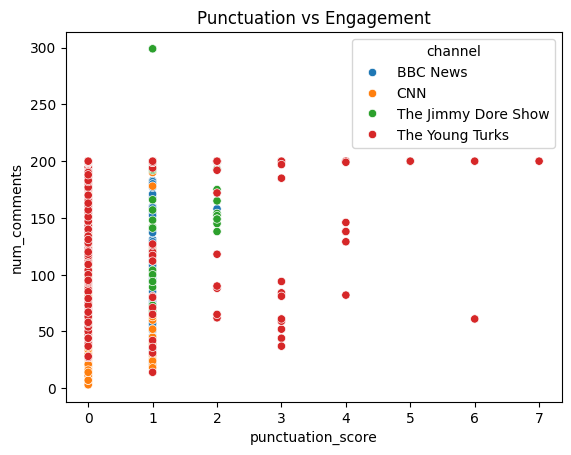

In [59]:
# correlation between punctuation score and number of comments
sns.scatterplot(data=engagement_df, x='punctuation_score', y='num_comments', hue='channel')
plt.title("Punctuation vs Engagement")
plt.show()


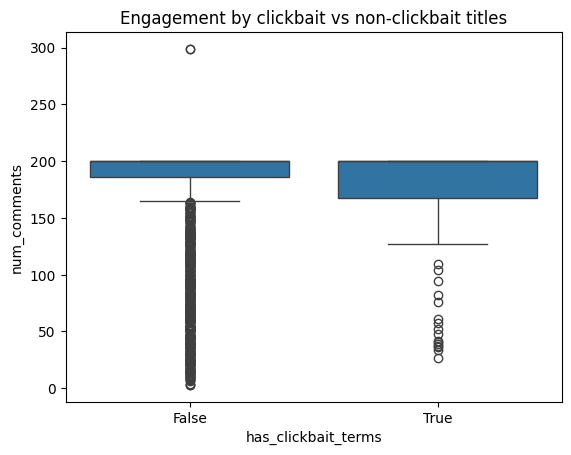

In [60]:
# clickbait vs non clickbait titles
sns.boxplot(data=engagement_df, x='has_clickbait_terms', y='num_comments')
plt.title("Engagement by clickbait vs non-clickbait titles")
plt.show()


These descriptive indicators provide an initial operationalization of clickbait based on formal and lexical features. However, they do not capture the emotional framing of content. Therefore, the next section applies linguistic preprocessing and sentiment and emotion analysis to further refine the concept of clickbait in terms of emotional tone.

## Text Preprocessing

All textual fields (titles, descriptions, and user comments) were preprocessed through a standard NLP pipeline including lowercasing, URL and punctuation removal, stopword filtering, and lemmatization using SpaCy, emojis removal and too short tokens removal. This step reduced linguistic noise for sentiment and topic analyses.

Because of the size of the dataframe, descriptions and titles will be pre-processed separately from the comments.

In [28]:
# Download NLTK
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')
stop_words = set(stopwords.words("english"))


# SpaCy model
nlp = spacy.load("en_core_web_sm")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [68]:
# Because of the size of the df a batching and parallelization functions was written for the comments
# A global variable to store the nlp object for each worker process
_nlp_worker = None

def clean_batch(batch):
    # Batch process
    global _nlp_worker
    if _nlp_worker is None:
        #loads the SpaCy model only once per worker
        _nlp_worker = spacy.load("en_core_web_sm", disable=["parser", "ner"])

    preprocessed = []
    for t in batch:
        t = t.lower()
        t = re.sub(r"http\S+|www\S+", "", t)  # Rimuovi URL
        t = emoji.replace_emoji(t, replace="")
        t = re.sub(r"[^a-z\s]", "", t)
        t = re.sub(r"\s+", " ", t).strip()
        preprocessed.append(t)

    cleaned = []
    for doc in _nlp_worker.pipe(preprocessed, batch_size=3000):
        tokens = [
            token.lemma_ for token in doc
            if not token.is_stop and len(token.lemma_) > 2
        ]
        cleaned.append(" ".join(tokens))
    return cleaned

def clean_text_spacy_pipe(df, columns=['comment_text'], n_jobs=-1, chunk_size=10000):

    for col in columns:
        print(f"Processing column: {col}")

        texts = df[col].fillna("").astype(str).tolist()
        chunks = [texts[i:i + chunk_size] for i in range(0, len(texts), chunk_size)]

        # Uses tqdm directly around the Parallel call to handle progress in the main process
        cleaned_chunks = Parallel(n_jobs=n_jobs)(
            delayed(clean_batch)(chunk) for chunk in tqdm(chunks, desc=f"Cleaning {col}")
        )

        cleaned_col = [item for sublist in cleaned_chunks for item in sublist]
        df[f'{col}_cleaned'] = cleaned_col

        if col == 'comment_text':
            df.to_pickle("checkpoint_after_comments_preprocessing.pkl")

    return df

In [98]:
# If error, load saved data with cleaned comments
df = pd.read_pickle("checkpoint_after_comments_preprocessing.pkl")
print(df.columns)
print(df.shape)

Index(['channel', 'video_id', 'video_timestamp', 'title', 'description',
       'comment_id', 'comment_author', 'comment_text', 'comment_likes',
       'comment_timestamp', 'comment_month', 'video_month', 'comment_date',
       'video_date', 'title_clean', 'has_clickbait_terms', 'punctuation_score',
       'uppercase_ratio', 'title_length', 'comment_text_cleaned'],
      dtype='object')
(450921, 20)


In [99]:
# Drop title_clean (previous proxy, just a lower case transformation)
df.drop(columns=['title_clean'], inplace=True)
df.columns

Index(['channel', 'video_id', 'video_timestamp', 'title', 'description',
       'comment_id', 'comment_author', 'comment_text', 'comment_likes',
       'comment_timestamp', 'comment_month', 'video_month', 'comment_date',
       'video_date', 'has_clickbait_terms', 'punctuation_score',
       'uppercase_ratio', 'title_length', 'comment_text_cleaned'],
      dtype='object')

In [74]:
# Sanity check
df[['comment_text', 'comment_text_cleaned']]

,comment_text,comment_text_cleaned
0,The sniffed up grifter is illegitimate anyhoo,sniff grifter illegitimate anyhoo
1,I think the situation on the front is not good...,think situation good good blaming start
2,Millions of pounds given to this country,million pound give country
3,A mean junky,mean junky
4,Nato created a monster which will eventually t...,nato create monster eventually turn west reap sow
...,...,...
451042,ed gallrein - woodshed vibes,gallrein woodshe vibe
451043,I'm worried about Massie's life at this point ...,worried massie life point know exactly zionist...
451044,"AIPAC, Zionist, globalist? Just say jew",aipac zionist globalist jew
451045,Thomas Massie for President and MTG for Vice P...,thomas massie president mtg vice president god...


In [80]:
# To avoid size issues;  Text pre processing on titles and descriptions is performed on unique ids
unique_videos = df[['video_id', 'title', 'description']].drop_duplicates(subset=['video_id'])

print(f"Unique videos: {len(unique_videos)}")

# Preprocessing function
def clean_unique(df_unique, col):
    texts = df_unique[col].fillna("").astype(str).tolist()
    nlp = spacy.load("en_core_web_sm", disable=["parser", "ner"])
    cleaned = []
    for text in tqdm(texts, desc=f"Cleaning unique {col}"):
        t = text.lower()
        t = re.sub(r"http\S+|www\S+", "", t)
        t = emoji.replace_emoji(t, replace="")
        t = re.sub(r"[^a-z\s]", "", t)
        t = re.sub(r"\s+", " ", t).strip()
        doc = nlp(t)
        tokens = [token.lemma_ for token in doc if not token.is_stop and len(token.lemma_) > 2]
        cleaned.append(" ".join(tokens))
    df_unique[f'{col}_cleaned'] = cleaned
    return df_unique

# Cleaning applied
unique_videos = clean_unique(unique_videos, 'title')
unique_videos = clean_unique(unique_videos, 'description')



Cleaning unique title:   0%|          | 0/2608 [00:00<?, ?it/s]

Cleaning unique title:   1%|          | 19/2608 [00:00<00:13, 189.31it/s]

Cleaning unique title:   1%|▏         | 38/2608 [00:00<00:13, 189.57it/s]

Cleaning unique title:   2%|▏         | 58/2608 [00:00<00:13, 191.82it/s]

Cleaning unique title:   3%|▎         | 79/2608 [00:00<00:12, 197.70it/s]

Cleaning unique title:   4%|▍         | 99/2608 [00:00<00:12, 193.44it/s]

Cleaning unique title:   5%|▍         | 120/2608 [00:00<00:12, 195.75it/s]

Cleaning unique title:   5%|▌         | 141/2608 [00:00<00:12, 197.68it/s]

Cleaning unique title:   6%|▌         | 161/2608 [00:00<00:12, 195.03it/s]

Cleaning unique title:   7%|▋         | 181/2608 [00:00<00:12, 192.37it/s]

Cleaning unique title:   8%|▊         | 201/2608 [00:01<00:12, 193.65it/s]

Cleaning unique title:   9%|▊         | 222/2608 [00:01<00:12, 197.52it/s]

Cleaning unique title:   9%|▉         | 247/2608 [00:01<00:11, 210.37it/s]

Cleaning unique title:  10

In [102]:
# Merge processed titles and descriptions back to comment df
df = df.merge(
    unique_videos[['video_id', 'title_cleaned', 'description_cleaned']],
    on='video_id',
    how='left'
)

df.to_pickle("final_cleaned_df.pkl")
df.to_csv("/content/drive/MyDrive/ANNO2/PRIMO PERIODO 2/SOCIAL MEDIA/PROJECT/content_df_cleaned.csv", index = False)

## Linguistic Analysis (Emotional Framing)

| Analysis            | Metric                   | Description                                      |
| ------------------- | ------------------------ | ------------------------------------------------ |
| **VADER Sentiment** | compound score           | emotional polarity (positive/negative/neutral)   |
| **NRC Emotions**    | anger, fear, joy, trust… | emotional tone distribution                      |
| **Correlation**     | sentiment ↔ engagement   | do emotional titles/comments get more reactions? |


### Lexical Patterns

In [108]:
# Definition of function for top 20 most frequent words and associated frequency
def get_top_words(df, text_col, channel, n=20):
    text = " ".join(df[df['channel'] == channel][text_col])
    words = text.split()
    return Counter(words).most_common(n)

In [109]:
# Word frequency in titles per channel (top 20)
channels = df['channel'].unique()

for ch in channels:
    print(f"\nTop words in titles for {ch}")
    print(get_top_words(df, 'title_cleaned', ch))



Top words in titles for BBC News
[('bbc', 91449), ('news', 79917), ('trump', 18598), ('say', 8939), ('donald', 8585), ('newscast', 8064), ('ukraine', 8060), ('president', 6793), ('global', 6303), ('podcast', 5880), ('greenland', 5311), ('peace', 5128), ('venezuela', 4556), ('epstein', 4308), ('new', 4259), ('iran', 4075), ('strike', 3922), ('talk', 3797), ('kill', 3671), ('fire', 3562)]

Top words in titles for CNN
[('trump', 58650), ('epstein', 12704), ('new', 11219), ('say', 10279), ('release', 8407), ('cnn', 8131), ('strike', 7872), ('house', 7195), ('file', 6905), ('enten', 6849), ('venezuela', 6362), ('ice', 5768), ('shooting', 5681), ('election', 5288), ('mamdani', 5286), ('video', 5165), ('react', 5116), ('shutdown', 4920), ('talk', 4873), ('boat', 4873)]

Top words in titles for The Young Turks
[('trump', 22985), ('epstein', 10153), ('israel', 9729), ('cenk', 7292), ('war', 6636), ('get', 6534), ('ice', 4832), ('ana', 4662), ('tucker', 4604), ('expose', 4550), ('new', 3918), (

In [111]:
# Word frequency in description per channel
for ch in channels:
    print(f"\nTop words in description for {ch}")
    print(get_top_words(df, 'description_cleaned', ch))


Top words in description for BBC News
[('news', 112268), ('say', 108895), ('subscribe', 93204), ('visit', 91798), ('feature', 90717), ('analysis', 90633), ('bbcnew', 78265), ('trump', 68375), ('president', 61502), ('bbc', 41481), ('ukraine', 33051), ('people', 32093), ('donald', 31626), ('year', 26073), ('new', 24663), ('greenland', 24059), ('country', 22149), ('russia', 21250), ('government', 20259), ('plan', 19442)]

Top words in description for CNN
[('cnn', 257226), ('news', 169871), ('trump', 120908), ('president', 95277), ('say', 57929), ('report', 55695), ('donald', 47339), ('speak', 46865), ('cnns', 46016), ('new', 44430), ('house', 44057), ('epstein', 28299), ('correspondent', 27908), ('white', 27660), ('chief', 26766), ('release', 23304), ('discuss', 22990), ('analyst', 22595), ('year', 21154), ('federal', 20946)]

Top words in description for The Young Turks
[('tyt', 1141195), ('news', 1038534), ('network', 737601), ('online', 555523), ('subscribe', 402511), ('young', 390284

In [112]:
# Word frequency in comments per channel
for ch in channels:
    print(f"\nTop words in comments for {ch}")
    print(get_top_words(df, "comment_text_cleaned", ch))


Top words in comments for BBC News
[('not', 15635), ('bbc', 13060), ('trump', 12908), ('people', 11915), ('like', 8888), ('country', 7134), ('world', 6376), ('war', 6013), ('ukraine', 5756), ('russia', 5418), ('want', 5338), ('need', 4860), ('know', 4777), ('year', 4712), ('time', 4485), ('news', 4165), ('good', 4011), ('come', 3992), ('government', 3835), ('think', 3480)]

Top words in comments for CNN
[('trump', 40125), ('not', 38846), ('people', 26043), ('like', 16716), ('know', 11921), ('cnn', 11692), ('want', 11174), ('need', 11055), ('country', 10901), ('president', 9844), ('america', 9592), ('time', 9333), ('year', 8862), ('good', 8726), ('say', 8332), ('think', 8243), ('get', 8115), ('come', 7859), ('world', 7815), ('war', 7425)]

Top words in comments for The Young Turks
[('not', 25503), ('trump', 15913), ('people', 15815), ('like', 12241), ('israel', 12060), ('know', 7927), ('want', 6829), ('think', 6591), ('say', 6465), ('need', 6264), ('right', 6253), ('country', 6046), ('

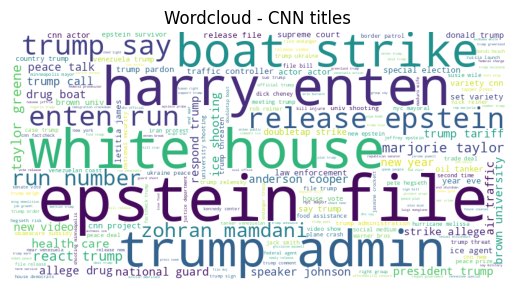

In [113]:
# Worldcloud titoli : CNN
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text = " ".join(df[df['channel']=="CNN"]['title_cleaned'])

wc = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.imshow(wc)
plt.axis('off')
plt.title("Wordcloud - CNN titles")
plt.show()


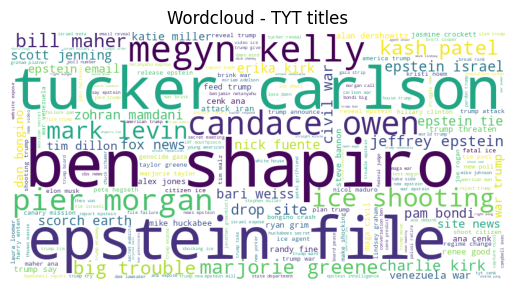

In [114]:
text = " ".join(df[df['channel']=="The Young Turks"]['title_cleaned'])

wc = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.imshow(wc)
plt.axis('off')
plt.title("Wordcloud - TYT titles")
plt.show()


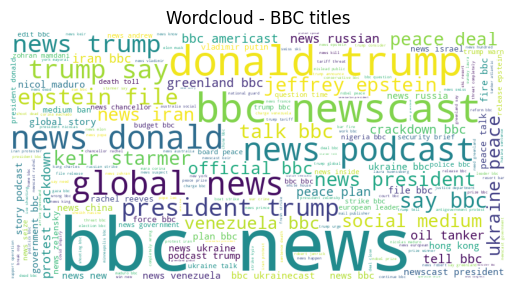

In [115]:
text = " ".join(df[df['channel']=="BBC News"]['title_cleaned'])

wc = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.imshow(wc)
plt.axis('off')
plt.title("Wordcloud - BBC titles")
plt.show()


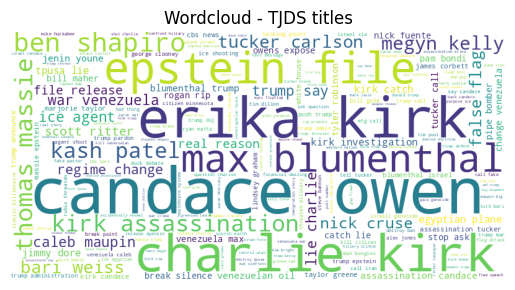

In [116]:
text = " ".join(df[df['channel']=="The Jimmy Dore Show"]['title_cleaned'])

wc = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.imshow(wc)
plt.axis('off')
plt.title("Wordcloud - TJDS titles")
plt.show()


### Topic modeling (LDA)

In [128]:
# Videos  info
videos_df = df[['video_id','channel','title_cleaned','description_cleaned']].drop_duplicates(subset='video_id')
videos_df['text_for_lda'] = videos_df['title_cleaned'] + " " + videos_df['description_cleaned']

# Unique channels
channels = df['channel'].unique()

We perform topic modeling first only on titles and secondly on titles and descriptions.

Just titles give us information on channels' framing, concatenating titles with descriptions helps us understand also the context.

#### Titles (framing)

In [125]:
# Definition of a function for selecting 5 topics; using gensim lib
def lda_for_channel_videos(videos_df, channel, num_topics=5):
    texts = videos_df[videos_df['channel'] == channel]['title_cleaned'] \
                .dropna() \
                .apply(lambda x: x.split()) \
                .tolist()

    dictionary = corpora.Dictionary(texts)
    corpus = [dictionary.doc2bow(text) for text in texts]

    lda_model = models.LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=num_topics,
        passes=10,
        random_state=42
    )

    return lda_model.print_topics()


In [126]:
# Loop for title topic
for ch in videos_df['channel'].unique():
    print(f"\nTopics for {ch}")
    topics = lda_for_channel_videos(videos_df, ch)
    for t in topics:
        print(t)


Topics for BBC News
(0, '0.076*"news" + 0.068*"bbc" + 0.016*"fire" + 0.016*"podcast" + 0.016*"global" + 0.009*"tanker" + 0.009*"kill" + 0.008*"medium" + 0.008*"social" + 0.008*"talk"')
(1, '0.045*"bbc" + 0.044*"news" + 0.029*"trump" + 0.021*"president" + 0.019*"global" + 0.018*"podcast" + 0.013*"ukraine" + 0.013*"venezuela" + 0.013*"say" + 0.010*"security"')
(2, '0.074*"bbc" + 0.057*"news" + 0.015*"newscast" + 0.010*"kill" + 0.010*"peace" + 0.010*"ukraine" + 0.009*"trump" + 0.008*"strike" + 0.006*"deal" + 0.006*"russian"')
(3, '0.092*"bbc" + 0.071*"news" + 0.025*"trump" + 0.019*"newscast" + 0.016*"donald" + 0.013*"epstein" + 0.013*"greenland" + 0.010*"say" + 0.010*"release" + 0.008*"ukraine"')
(4, '0.110*"bbc" + 0.095*"news" + 0.013*"trump" + 0.009*"say" + 0.008*"donald" + 0.007*"protest" + 0.007*"president" + 0.006*"iran" + 0.006*"new" + 0.005*"government"')

Topics for CNN
(0, '0.034*"trump" + 0.008*"official" + 0.008*"new" + 0.008*"ice" + 0.007*"talk" + 0.007*"year" + 0.007*"say" +

#### Titles and description (topics)

In [129]:
def lda_for_channel_videos(videos_df, channel, num_topics=5):
    texts = videos_df[videos_df['channel']==channel]['text_for_lda'] \
            .dropna() \
            .apply(lambda x: x.split()) \
            .tolist()

    dictionary = corpora.Dictionary(texts)
    corpus = [dictionary.doc2bow(text) for text in texts]

    lda_model = models.LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=num_topics,
        passes=10,
        random_state=42
    )

    return lda_model.print_topics()

In [130]:
# Loop for titles+descriptions
for ch in videos_df['channel'].unique():
    print(f"\nTopics for {ch}")
    topics = lda_for_channel_videos(videos_df, ch)
    for t in topics:
        print(t)


Topics for BBC News
(0, '0.023*"news" + 0.013*"bbc" + 0.013*"say" + 0.012*"visit" + 0.012*"feature" + 0.011*"subscribe" + 0.011*"analysis" + 0.010*"iran" + 0.009*"bbcnew" + 0.008*"people"')
(1, '0.019*"news" + 0.018*"epstein" + 0.012*"release" + 0.012*"trump" + 0.011*"bbc" + 0.011*"say" + 0.010*"feature" + 0.009*"analysis" + 0.009*"file" + 0.009*"subscribe"')
(2, '0.027*"news" + 0.017*"bbc" + 0.015*"say" + 0.013*"visit" + 0.013*"subscribe" + 0.013*"analysis" + 0.013*"feature" + 0.010*"bbcnew" + 0.008*"people" + 0.008*"venezuela"')
(3, '0.027*"news" + 0.019*"say" + 0.017*"ukraine" + 0.014*"greenland" + 0.014*"bbc" + 0.013*"trump" + 0.013*"subscribe" + 0.012*"visit" + 0.012*"feature" + 0.012*"president"')
(4, '0.026*"news" + 0.025*"bbc" + 0.013*"subscribe" + 0.013*"analysis" + 0.012*"visit" + 0.012*"feature" + 0.012*"bbcnew" + 0.012*"trump" + 0.010*"say" + 0.009*"newscast"')

Topics for CNN
(0, '0.036*"cnn" + 0.017*"news" + 0.016*"trump" + 0.010*"president" + 0.009*"underscore" + 0.008*

### Sentiment Analysis (VADER)

Sentiment analysis was applied to titles, descriptions, and user comments in order to compare emotional framing strategies with audience emotional responses.



In [139]:
# Load analyzer and associate continuous score to each video (title, description , comment)
analyzer = SentimentIntensityAnalyzer()

df['title_sentiment'] = df['title_cleaned'].apply(lambda x: analyzer.polarity_scores(x)['compound'])
df['comment_sentiment'] = df['comment_text_cleaned'].apply(lambda x: analyzer.polarity_scores(x)['compound'])
df['description_sentiment']= df['description_cleaned'].apply(lambda x: analyzer.polarity_scores(x)['compound'])

df.to_csv("/content/drive/MyDrive/ANNO2/PRIMO PERIODO 2/SOCIAL MEDIA/PROJECT/content_df_cleaned_sentiment.csv")

In [ ]:
# If error/time consuming, load previously downloaded data
df = pd.read_csv("/content/drive/MyDrive/ANNO2/PRIMO PERIODO 2/SOCIAL MEDIA/PROJECT/content_df_cleaned_sentiment.csv")

In [7]:
# Since df has comments granularity, we use two separate dfs
# Video average sentiment by channel
video_sentiment = df.drop_duplicates('video_id')[['video_id','channel','title_sentiment','description_sentiment']]

# Calculate mean only for sentiment  video columns
video_sentiment = video_sentiment.groupby('channel')[['title_sentiment', 'description_sentiment']].mean().reset_index()

video_sentiment

,channel,title_sentiment,description_sentiment
0,BBC News,-0.138706,-0.182879
1,CNN,-0.075917,-0.009744
2,The Jimmy Dore Show,-0.201818,0.583660
3,The Young Turks,-0.203613,0.839830


In [8]:
# Comment average sentiment by channel
comment_sentiment= df.groupby('channel')['comment_sentiment'].mean().reset_index()

comment_sentiment

,channel,comment_sentiment
0,BBC News,-0.065946
1,CNN,-0.070886
2,The Jimmy Dore Show,-0.049976
3,The Young Turks,-0.085147


In [9]:
# Merge: sentiment metric per channel
sentiment_all = video_sentiment.merge(comment_sentiment, on= 'channel')

sentiment_all

,channel,title_sentiment,description_sentiment,comment_sentiment
0,BBC News,-0.138706,-0.182879,-0.065946
1,CNN,-0.075917,-0.009744,-0.070886
2,The Jimmy Dore Show,-0.201818,0.583660,-0.049976
3,The Young Turks,-0.203613,0.839830,-0.085147


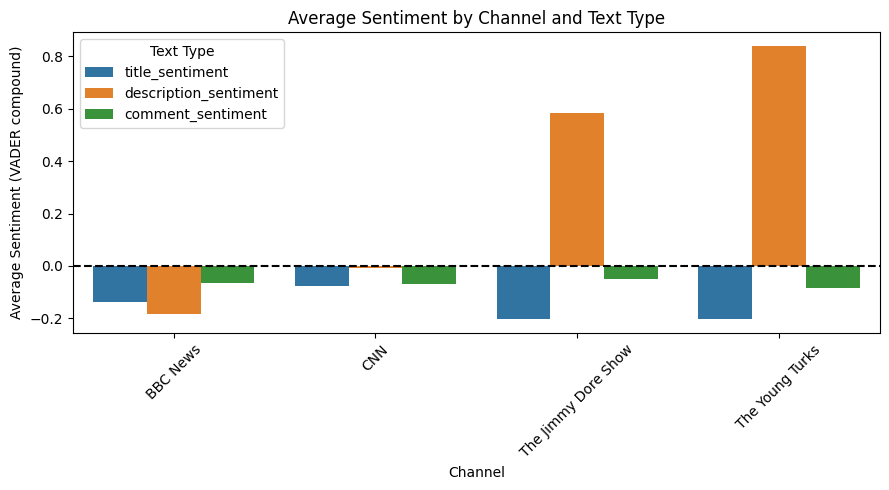

In [11]:
# Comparison on average continuous score on titles, description and comments (across all channels)
sentiment_long = sentiment_all.melt(
    id_vars='channel',
    value_vars=['title_sentiment', 'description_sentiment', 'comment_sentiment'],
    var_name='text_type',
    value_name='avg_sentiment'
)

plt.figure(figsize=(9,5))
sns.barplot(data=sentiment_long, x='channel', y='avg_sentiment', hue='text_type')

plt.axhline(0, color='black', linestyle='--')
plt.title("Average Sentiment by Channel and Text Type")
plt.ylabel("Average Sentiment (VADER compound)")
plt.xlabel("Channel")
plt.xticks(rotation=45)
plt.legend(title="Text Type")
plt.tight_layout()
plt.show()


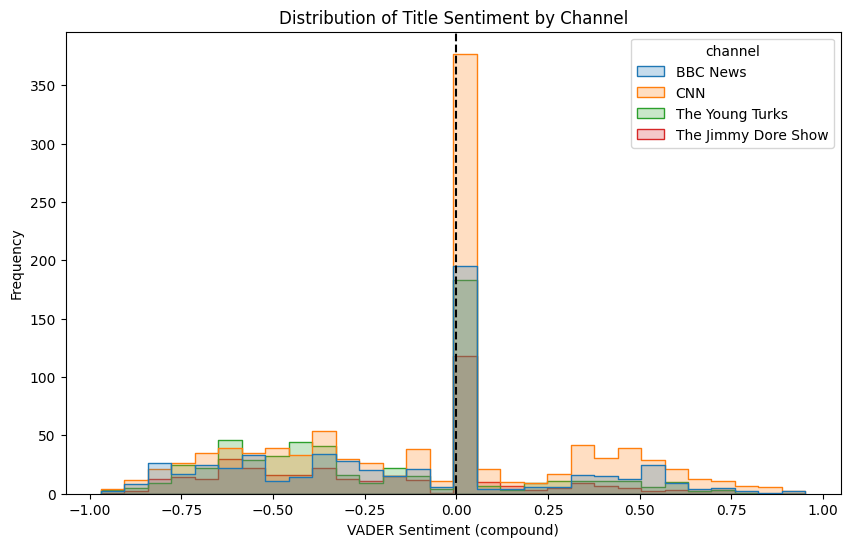

In [158]:
# Titles sentiment distribution by channel; titles seem to be more negative than positive
titles_df = df.drop_duplicates('video_id')[['channel', 'title_sentiment']]

plt.figure(figsize=(10,6))
sns.histplot(
    data=titles_df,
    x='title_sentiment',
    hue='channel',
    bins=30,
    element='step',
)

plt.axvline(0, color='black', linestyle='--')
plt.title("Distribution of Title Sentiment by Channel")
plt.xlabel("VADER Sentiment (compound)")
plt.ylabel("Frequency")
plt.show()


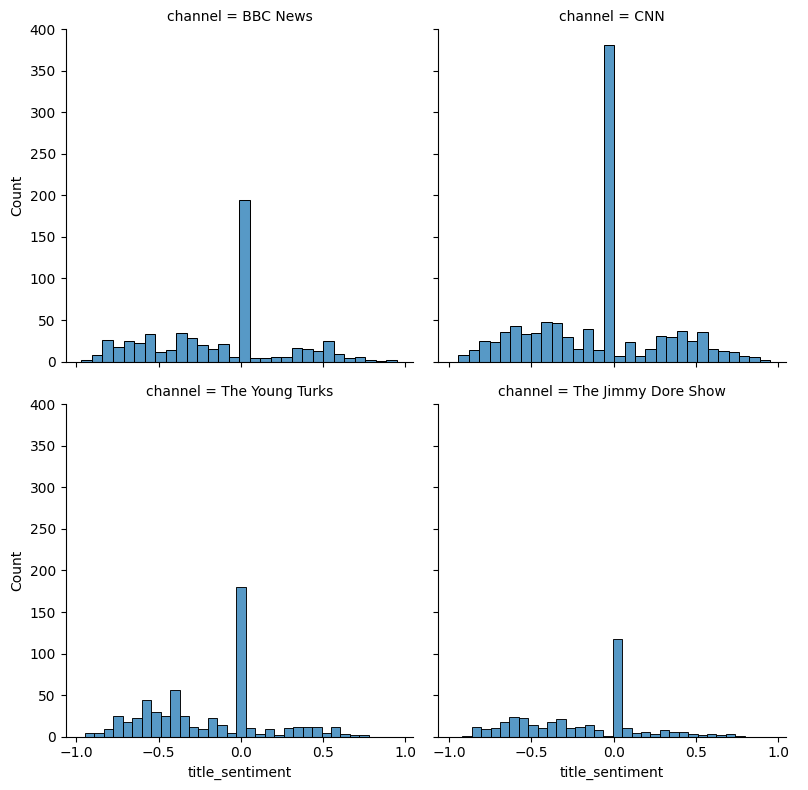

In [160]:
g = sns.FacetGrid(titles_df, col="channel", col_wrap=2, height=4, sharex=True, sharey=True)
g.map(sns.histplot, "title_sentiment", bins=30)
g.add_legend()


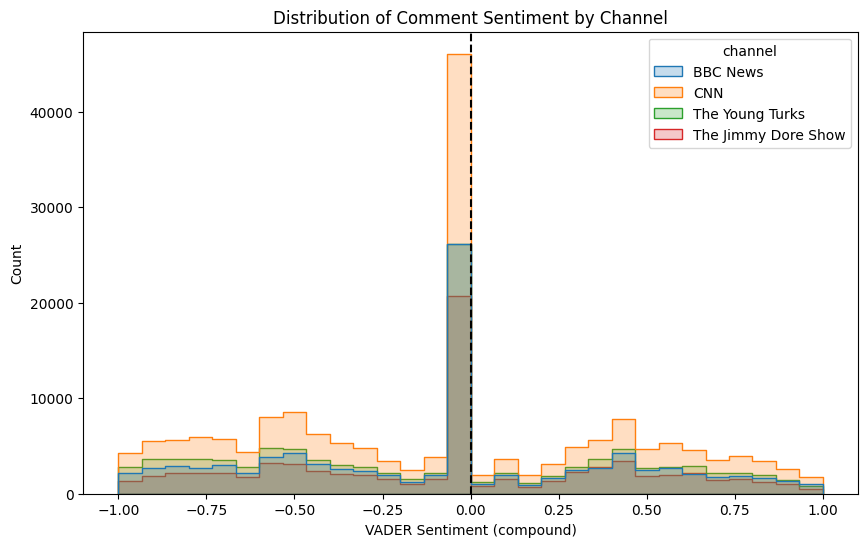

In [161]:
# Comment sentiment distribution; Bimodal distribution --> polirized emotions in the comments
comments_df = df[['channel', 'comment_sentiment']]
plt.figure(figsize=(10,6))
sns.histplot(
    data=comments_df,
    x='comment_sentiment',
    hue='channel',
    bins=30,
    element='step'
)

plt.axvline(0, color='black', linestyle='--')
plt.title("Distribution of Comment Sentiment by Channel")
plt.xlabel("VADER Sentiment (compound)")
plt.ylabel("Count")
plt.show()


In [12]:
# Title sentiment vs Avg Comment sentiment per video: pearson correlation
comment_sentiment_per_video = df.groupby('video_id')['comment_sentiment'].mean().reset_index(name='avg_comment_sentiment')
title_sentiment_per_video = df.drop_duplicates('video_id')[['video_id', 'channel', 'title_sentiment']]
sentiment_video_df = title_sentiment_per_video.merge(
    comment_sentiment_per_video,
    on='video_id'
)

corr = sentiment_video_df['title_sentiment'].corr(sentiment_video_df['avg_comment_sentiment'])
print("Correlation title sentiment vs comment sentiment:", corr)


Correlation title sentiment vs comment sentiment: 0.35927822241079244


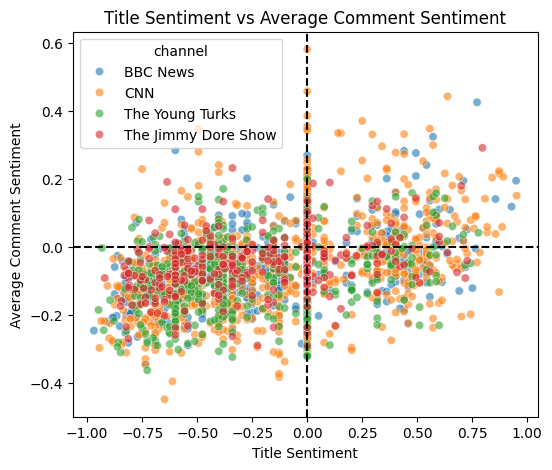

In [163]:
plt.figure(figsize=(6,5))
sns.scatterplot(
    data=sentiment_video_df,
    x='title_sentiment',
    y='avg_comment_sentiment',
    hue='channel',
    alpha=0.6
)

plt.axhline(0, color='black', linestyle='--')
plt.axvline(0, color='black', linestyle='--')
plt.title("Title Sentiment vs Average Comment Sentiment")
plt.xlabel("Title Sentiment")
plt.ylabel("Average Comment Sentiment")
plt.show()


In [16]:
# Title sentiment vs Avg Comment sentiment per video (per channel): pearson correlation
# Do alternative channels have a stronger correlation? --> It might indicate a more efficient framing
correlations = sentiment_video_df.groupby('channel').apply(
    lambda x: x['title_sentiment'].corr(x['avg_comment_sentiment'])
)

correlations_df = correlations.reset_index(name='correlation')
print(correlations_df)


               channel  correlation
0             BBC News     0.422188
1                  CNN     0.369221
2  The Jimmy Dore Show     0.310793
3      The Young Turks     0.297929


/tmp/ipython-input-3101961002.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  correlations = sentiment_video_df.groupby('channel').apply(


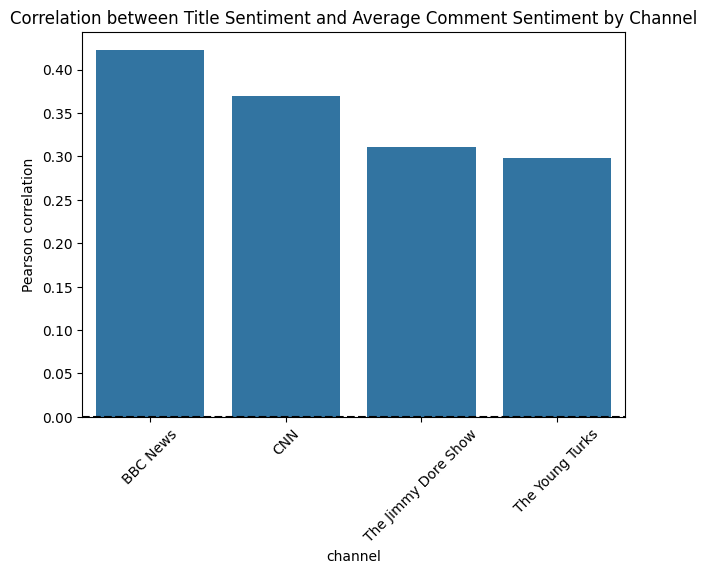

In [17]:
# Correlations of titles sentiment score and avg sentiment on comments across channels; Indicator of emotional alignment;
plt.figure(figsize=(7,5))
sns.barplot(data=correlations_df, x='channel', y='correlation')
plt.axhline(0, color='black', linestyle='--')
plt.title("Correlation between Title Sentiment and Average Comment Sentiment by Channel")
plt.ylabel("Pearson correlation")
plt.xticks(rotation=45)
plt.show()


### Emotion Analysis (NRC)

Emotion analysis was conducted using the NRC Emotion Lexicon through the NRCLex library. Each text (title, description, and comment) was associated with eight basic emotions (anger, fear, anticipation, trust, surprise, sadness, joy, disgust).

In [41]:
# Create emotion labels
emotion_labels = ['anger','fear','anticipation','trust','surprise','sadness','joy','disgust']

# Define a function
def get_emotions(text):
    if pd.isna(text) or text.strip()=="":
        return dict.fromkeys(emotion_labels, 0)

    emotion = NRCLex(text)
    scores = emotion.raw_emotion_scores

    return {e: scores.get(e, 0) for e in emotion_labels}


#### Titles

In [45]:
video_df = df.drop_duplicates('video_id')[['video_id','channel','title_cleaned', 'description_cleaned']]

title_emotions = video_df['title_cleaned'].apply(get_emotions)
title_emotions_df = pd.DataFrame(list(title_emotions))

title_df = pd.concat([video_df.reset_index(drop=True), title_emotions_df], axis=1)


In [46]:
title_df

,video_id,channel,title_cleaned,description_cleaned,anger,fear,anticipation,trust,surprise,sadness,joy,disgust
0,JiUoqt4cMrU,BBC News,ukraine president zelensky criticise europe av...,speech world leader ukraine president volodymy...,0,1,0,1,0,0,0,0
1,LgPQtGMUXAc,BBC News,canada lead global resistance trump global sto...,canadian prime minister mark carney challenge ...,1,0,0,0,1,0,0,0
2,bALbBkpC3bc,BBC News,donald trump launches board peace world leader...,president donald trump say board peace work un...,0,0,2,2,1,0,1,0
3,H-ZzXK0ObNw,BBC News,hold join trump board peace putin concern bbc ...,foreign secretary yvette cooper say country wi...,0,0,2,1,1,0,1,0
4,BY11cl7ZrC0,BBC News,donald trump backtrack force greenland drop ne...,donald trump back greenland rule previous thre...,2,1,0,1,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...
2603,fdvbWUQ1Zxk,The Jimmy Dore Show,tpusa execs gaslight mikey mccoy bizarre actio...,recently question dominant narrative surround ...,1,1,0,0,1,1,0,0
2604,gyTF9A6Y-h4,The Jimmy Dore Show,kash patel shut charlie kirk investigation tul...,fbi director kash patel trump administration r...,0,0,1,0,0,0,0,0
2605,R8tyImlJumk,The Jimmy Dore Show,new jimmy dore hip hop track fire,new aigenerate rap song jimmy dore political c...,0,1,1,0,0,0,0,0
2606,czgU8RC7WBg,The Jimmy Dore Show,antiviolence actor michael rapaport attack fel...,recent antimamdani rally new york city actor m...,1,1,0,2,0,0,0,0


In [47]:
# Emotion dominance (average score per emotion) for titles by channel
emotion_by_channel_titles = title_df.groupby('channel')[emotion_labels].mean().reset_index()
emotion_by_channel_titles


,channel,anger,fear,anticipation,trust,surprise,sadness,joy,disgust
0,BBC News,0.524618,0.750424,0.475382,0.590832,0.390492,0.370119,0.219015,0.185059
1,CNN,0.578348,0.634378,0.445394,0.571700,0.527066,0.380817,0.264957,0.194682
2,The Jimmy Dore Show,0.529255,0.609043,0.255319,0.313830,0.369681,0.388298,0.146277,0.228723
3,The Young Turks,0.486441,0.577966,0.250847,0.271186,0.471186,0.286441,0.133898,0.206780


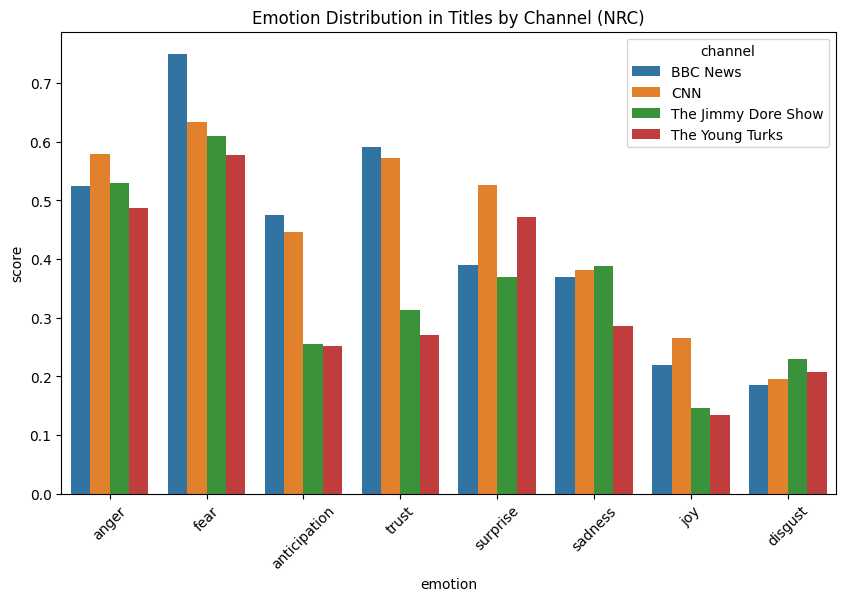

In [48]:
emotion_melt = emotion_by_channel_titles.melt(id_vars='channel', var_name='emotion', value_name='score')

plt.figure(figsize=(10,6))
sns.barplot(data=emotion_melt, x='emotion', y='score', hue='channel')
plt.title("Emotion Distribution in Titles by Channel (NRC)")
plt.xticks(rotation=45)
plt.show()


#### Descriptions

In [54]:
description_emotions = video_df['description_cleaned'].apply(get_emotions)
description_emotions_df = pd.DataFrame(list(description_emotions))

description_df = pd.concat([video_df.reset_index(drop=True), description_emotions_df], axis=1)

In [50]:
description_df

,video_id,channel,title_cleaned,description_cleaned,anger,fear,anticipation,trust,surprise,sadness,joy,disgust
0,JiUoqt4cMrU,BBC News,ukraine president zelensky criticise europe av...,speech world leader ukraine president volodymy...,0,1,0,1,0,0,0,0
1,LgPQtGMUXAc,BBC News,canada lead global resistance trump global sto...,canadian prime minister mark carney challenge ...,1,0,0,0,1,0,0,0
2,bALbBkpC3bc,BBC News,donald trump launches board peace world leader...,president donald trump say board peace work un...,0,0,2,2,1,0,1,0
3,H-ZzXK0ObNw,BBC News,hold join trump board peace putin concern bbc ...,foreign secretary yvette cooper say country wi...,0,0,2,1,1,0,1,0
4,BY11cl7ZrC0,BBC News,donald trump backtrack force greenland drop ne...,donald trump back greenland rule previous thre...,2,1,0,1,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...
2603,fdvbWUQ1Zxk,The Jimmy Dore Show,tpusa execs gaslight mikey mccoy bizarre actio...,recently question dominant narrative surround ...,1,1,0,0,1,1,0,0
2604,gyTF9A6Y-h4,The Jimmy Dore Show,kash patel shut charlie kirk investigation tul...,fbi director kash patel trump administration r...,0,0,1,0,0,0,0,0
2605,R8tyImlJumk,The Jimmy Dore Show,new jimmy dore hip hop track fire,new aigenerate rap song jimmy dore political c...,0,1,1,0,0,0,0,0
2606,czgU8RC7WBg,The Jimmy Dore Show,antiviolence actor michael rapaport attack fel...,recent antimamdani rally new york city actor m...,1,1,0,2,0,0,0,0


In [55]:
# Emotion dominance for descriptions by channel
emotion_by_channel_description= description_df.groupby('channel')[emotion_labels].mean().reset_index()
emotion_by_channel_description

,channel,anger,fear,anticipation,trust,surprise,sadness,joy,disgust
0,BBC News,3.159593,4.417657,4.249576,5.100170,2.030560,2.402377,1.694397,1.185059
1,CNN,1.792023,2.239316,2.073124,3.747388,1.447293,1.191833,1.183286,0.708452
2,The Jimmy Dore Show,4.763298,6.287234,9.361702,9.579787,2.851064,3.002660,3.757979,3.010638
3,The Young Turks,11.694915,11.225424,28.759322,28.989831,13.403390,8.866102,17.583051,5.681356


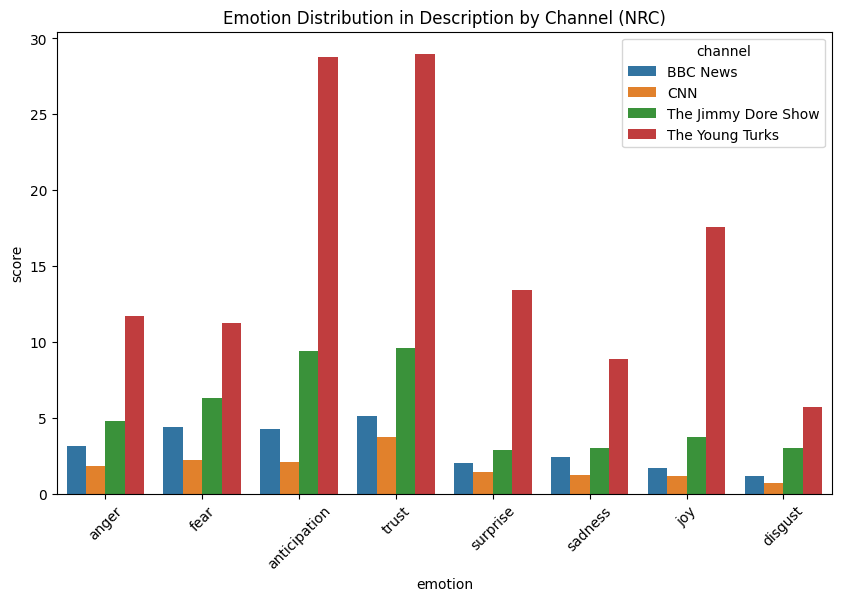

In [56]:
emotion_melt = emotion_by_channel_description.melt(id_vars='channel', var_name='emotion', value_name='score')

plt.figure(figsize=(10,6))
sns.barplot(data=emotion_melt, x='emotion', y='score', hue='channel')
plt.title("Emotion Distribution in Description by Channel (NRC)")
plt.xticks(rotation=45)
plt.show()

#### Comments

In [29]:
# Because of the number of comments, we define a separate function for processing them
# Processed in batches
def process_comments_batch(batch_texts):
    emotions_list = []
    for text in batch_texts:
        emotions = get_emotions(text)
        emotions_list.append(emotions)
    return emotions_list

# To maximize colabs usage we pararelize the process
def apply_emotions_to_comments(df, col='comment_text_cleaned', n_jobs=-1, chunk_size=10000):
    texts = df[col].fillna("").astype(str).tolist()
    chunks = [texts[i:i + chunk_size] for i in range(0, len(texts), chunk_size)]

    emotions_chunks = Parallel(n_jobs=n_jobs)(
        delayed(process_comments_batch)(chunk) for chunk in tqdm(chunks, desc="Emotions su commenti")
    )

    emotions_list = [item for sublist in emotions_chunks for item in sublist]

    emotions_df = pd.DataFrame(emotions_list)
    emotions_df.columns = [f"{e}_comment" for e in emotion_labels]

    df = pd.concat([df, emotions_df], axis=1)

    return df

# Execution
df = apply_emotions_to_comments(df, n_jobs=-1)



Emotions su commenti:   0%|          | 0/46 [00:00<?, ?it/s]

Emotions su commenti:   4%|▍         | 2/46 [00:00<00:02, 16.80it/s]

Emotions su commenti:   9%|▊         | 4/46 [00:06<01:16,  1.82s/it]

Emotions su commenti:  13%|█▎        | 6/46 [00:08<01:04,  1.61s/it]

Emotions su commenti:  17%|█▋        | 8/46 [00:11<00:56,  1.49s/it]

Emotions su commenti:  22%|██▏       | 10/46 [00:15<01:00,  1.69s/it]

Emotions su commenti:  26%|██▌       | 12/46 [00:18<00:55,  1.64s/it]

Emotions su commenti:  30%|███       | 14/46 [00:21<00:49,  1.54s/it]

Emotions su commenti:  35%|███▍      | 16/46 [00:23<00:43,  1.45s/it]

Emotions su commenti:  39%|███▉      | 18/46 [00:26<00:39,  1.42s/it]

Emotions su commenti:  43%|████▎     | 20/46 [00:30<00:39,  1.53s/it]

Emotions su commenti:  48%|████▊     | 22/46 [00:33<00:39,  1.63s/it]

Emotions su commenti:  52%|█████▏    | 24/46 [00:36<00:33,  1.52s/it]

Emotions su commenti:  57%|█████▋    | 26/46 [00:39<00:29,  1.46s/it]

Emotions su comme

Emotions su commenti completate!


In [34]:
# Emotion dominance by channel;
emotion_cols = [f"{e}_comment" for e in emotion_labels]
emotion_by_channel_comments = df.groupby('channel')[emotion_cols].mean().reset_index()
emotion_by_channel_comments

,channel,anger_comment,fear_comment,anticipation_comment,trust_comment,surprise_comment,sadness_comment,joy_comment,disgust_comment
0,BBC News,0.910361,1.193978,0.848503,1.212826,0.593875,0.800817,0.656303,0.595448
1,CNN,0.952038,1.146857,0.851287,1.210345,0.684984,0.837723,0.673494,0.667512
2,The Jimmy Dore Show,0.808227,0.988474,0.725152,1.027379,0.490747,0.688453,0.570284,0.550607
3,The Young Turks,0.982530,1.153752,0.812192,1.140832,0.606401,0.836321,0.641749,0.703649


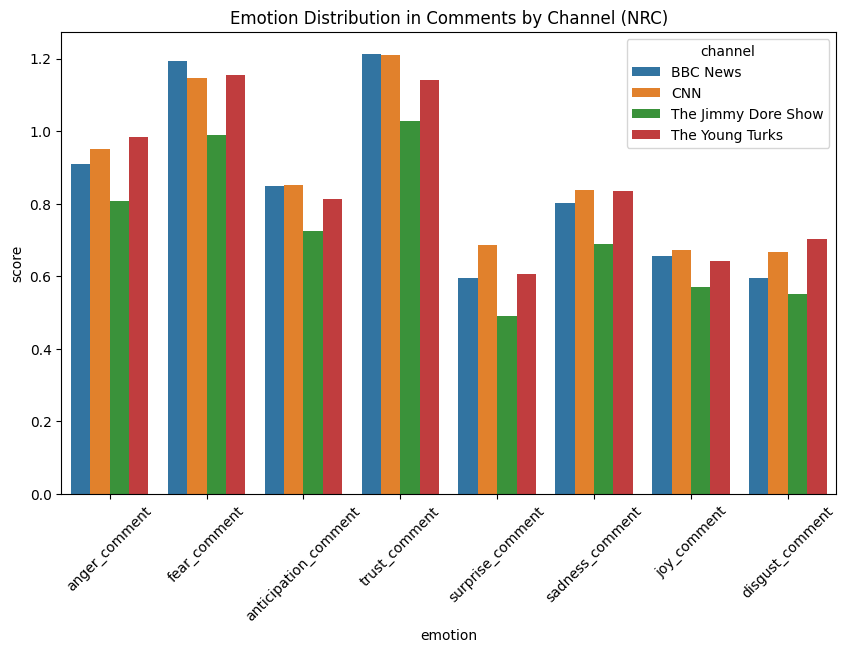

In [35]:
emotion_melt_c = emotion_by_channel_comments.melt(id_vars='channel', var_name='emotion', value_name='score')

plt.figure(figsize=(10,6))
sns.barplot(data=emotion_melt_c, x='emotion', y='score', hue='channel')
plt.title("Emotion Distribution in Comments by Channel (NRC)")
plt.xticks(rotation=45)
plt.show()


#### Production vs Reaction

Question to answer in this section:
- Do the emotions used by channels in their content production translate into similar emotional reactions among users? Are the average emotional profiles of titles and comments aligned within each channel?

In [57]:
# Create a full dataset with average emotions scores per emotion; concatenate info for comments and titles;
comparison = emotion_by_channel_titles.merge(
    emotion_by_channel_comments,
    on='channel'
)

comparison

,channel,anger,fear,anticipation,trust,surprise,sadness,joy,disgust,anger_comment,fear_comment,anticipation_comment,trust_comment,surprise_comment,sadness_comment,joy_comment,disgust_comment
0,BBC News,0.524618,0.750424,0.475382,0.590832,0.390492,0.370119,0.219015,0.185059,0.910361,1.193978,0.848503,1.212826,0.593875,0.800817,0.656303,0.595448
1,CNN,0.578348,0.634378,0.445394,0.571700,0.527066,0.380817,0.264957,0.194682,0.952038,1.146857,0.851287,1.210345,0.684984,0.837723,0.673494,0.667512
2,The Jimmy Dore Show,0.529255,0.609043,0.255319,0.313830,0.369681,0.388298,0.146277,0.228723,0.808227,0.988474,0.725152,1.027379,0.490747,0.688453,0.570284,0.550607
3,The Young Turks,0.486441,0.577966,0.250847,0.271186,0.471186,0.286441,0.133898,0.206780,0.982530,1.153752,0.812192,1.140832,0.606401,0.836321,0.641749,0.703649


In [58]:
# Change format for visual representation
emotion_labels = ['anger','fear','anticipation','trust','surprise','sadness','joy','disgust']

long_df = []

for emo in emotion_labels:
    temp = comparison[['channel', emo, emo + '_comment']].copy()
    temp = temp.rename(columns={
        emo: 'title_score',
        emo + '_comment': 'comment_score'
    })
    temp = temp.melt(id_vars='channel',
                     value_vars=['title_score','comment_score'],
                     var_name='source',
                     value_name='score')
    temp['emotion'] = emo
    long_df.append(temp)

long_df = pd.concat(long_df, ignore_index=True)
long_df

,channel,source,score,emotion
0,BBC News,title_score,0.524618,anger
1,CNN,title_score,0.578348,anger
2,The Jimmy Dore Show,title_score,0.529255,anger
3,The Young Turks,title_score,0.486441,anger
4,BBC News,comment_score,0.910361,anger
...,...,...,...,...
59,The Young Turks,title_score,0.206780,disgust
60,BBC News,comment_score,0.595448,disgust
61,CNN,comment_score,0.667512,disgust
62,The Jimmy Dore Show,comment_score,0.550607,disgust


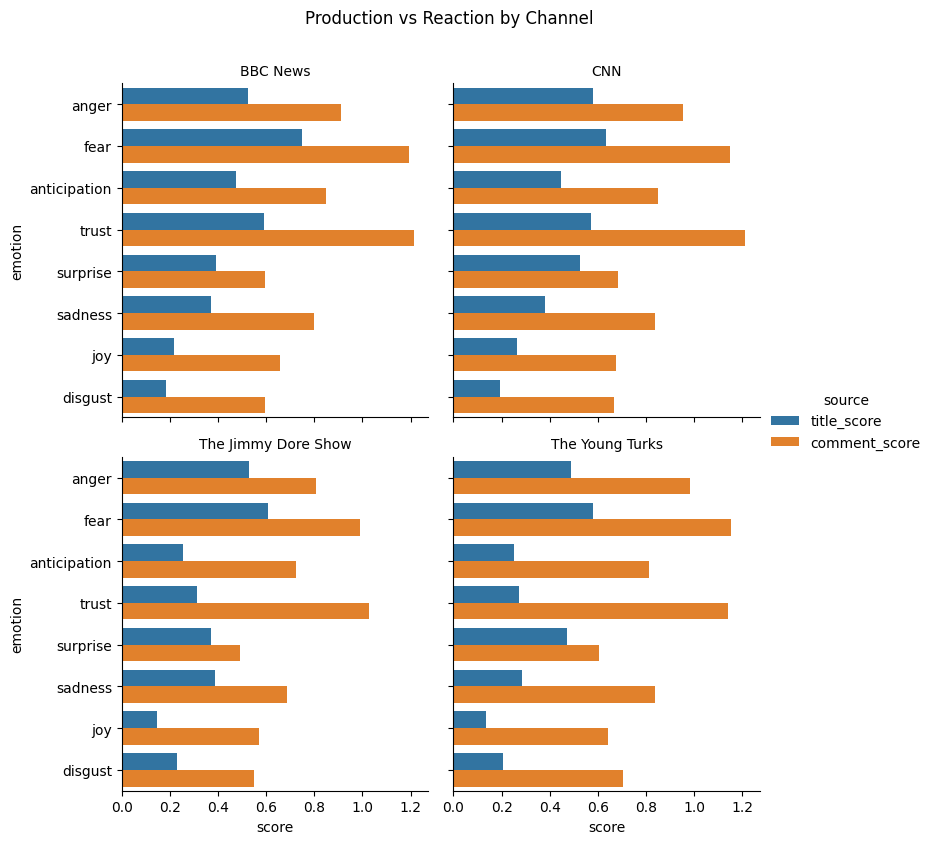

In [65]:
# Visual comparison average emotion on titles vs description per channel;
g = sns.catplot(
    data=long_df,
    y='emotion', x='score', hue='source',
    col='channel',
    kind='bar',
    col_wrap=2,
    height=4, aspect=1
)

g.set_titles("{col_name}")
g.fig.suptitle("Production vs Reaction by Channel", y=1.05)
plt.show()


### Emotion and Engagement

Do emotionally charged titles and comments generate higher audience engagement?

In [67]:
# Video granularity df
video_engagement = title_df.merge(
    df.groupby('video_id').size().reset_index(name='num_comments'),
    on='video_id'
)

In [70]:
# Correlation
emotion_labels = ['anger','fear','anticipation','trust','surprise','sadness','joy','disgust']

corr_results = []

for emo in emotion_labels:
    corr = video_engagement[emo].corr(video_engagement['num_comments'])
    corr_results.append({'emotion': emo, 'correlation': corr})

corr_df = pd.DataFrame(corr_results)
corr_df


,emotion,correlation
0,anger,0.065526
1,fear,0.013646
2,anticipation,-0.022004
3,trust,0.021575
4,surprise,0.074958
5,sadness,-0.020572
6,joy,-0.050523
7,disgust,-0.011160


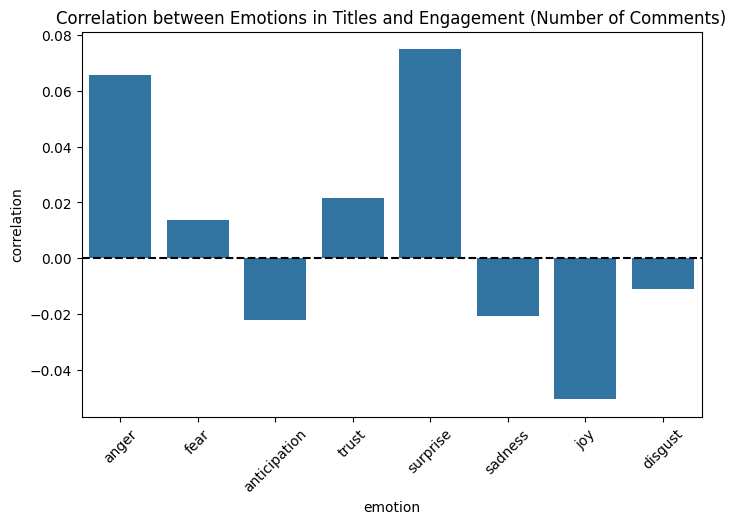

In [71]:
# barplot
plt.figure(figsize=(8,5))
sns.barplot(data=corr_df, x='emotion', y='correlation')
plt.axhline(0, color='black', linestyle='--')
plt.title("Correlation between Emotions in Titles and Engagement (Number of Comments)")
plt.xticks(rotation=45)
plt.show()


In [73]:
# correlation by channel
corr_channel = []

for channel in video_engagement['channel'].unique():
    df_c = video_engagement[video_engagement['channel'] == channel]
    for emo in emotion_labels:
        corr = df_c[emo].corr(df_c['num_comments'])
        corr_channel.append({
            'channel': channel,
            'emotion': emo,
            'correlation': corr
        })

corr_channel_df = pd.DataFrame(corr_channel)
corr_channel_df


,channel,emotion,correlation
0,BBC News,anger,0.098521
1,BBC News,fear,0.010019
2,BBC News,anticipation,0.045487
3,BBC News,trust,0.100922
4,BBC News,surprise,0.163913
5,BBC News,sadness,-0.052559
6,BBC News,joy,-0.009033
7,BBC News,disgust,0.002444
8,CNN,anger,0.124082
9,CNN,fear,0.101070


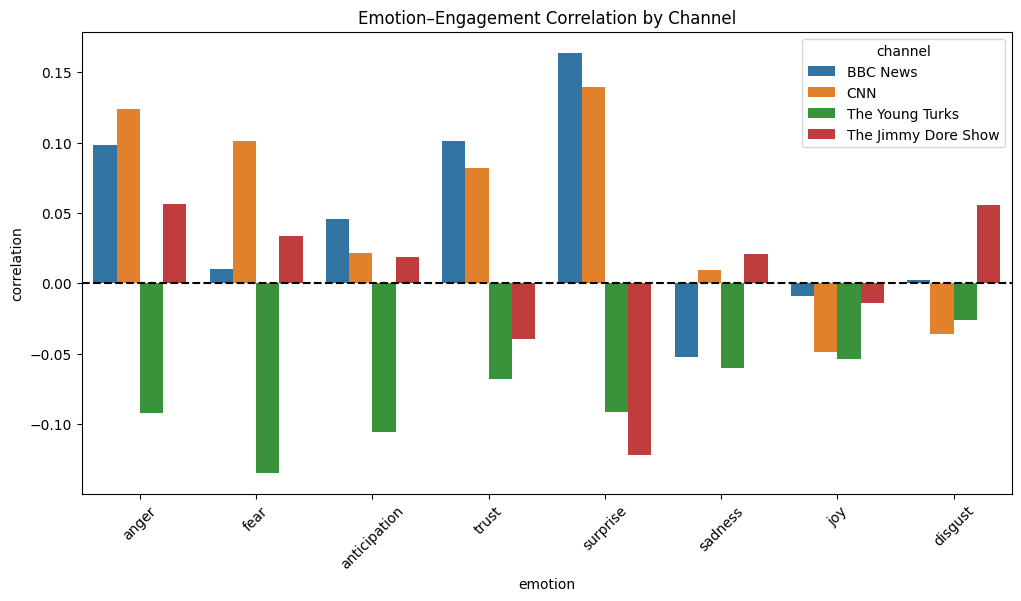

In [74]:
plt.figure(figsize=(12,6))
sns.barplot(data=corr_channel_df, x='emotion', y='correlation', hue='channel')
plt.axhline(0, color='black', linestyle='--')
plt.title("Emotion–Engagement Correlation by Channel")
plt.xticks(rotation=45)
plt.show()


## Network Analysis

Assumptions:
- last 15 days videos per channel (time horizon 5/1 - 20/1)
- for those videos only 1500 most liked comments per channel were chosen; giving us a tot of 6000 comments sampled;
- finally a max of 20 replies were fetched for each of those comments;

In [8]:
# Load interaction_df; previously created on data collection
replies_df = pd.read_csv("/content/drive/MyDrive/ANNO2/PRIMO PERIODO 2/SOCIAL MEDIA/PROJECT/interaction_df.csv")
replies_df.shape

(10456, 17)

In [9]:
# Recall available variables
replies_df.columns

Index(['Unnamed: 0', 'parent_id', 'reply_id', 'reply_author', 'reply_text',
       'reply_likes', 'reply_timestamp', 'video_id', 'channel_id',
       'comment_id', 'comment_author', 'comment_text', 'comment_likes',
       'comment_timestamp', 'title', 'description', 'video_timestamp'],
      dtype='object')

In [12]:
# Snippet
replies_df.head()

,Unnamed: 0,parent_id,reply_id,reply_author,reply_text,reply_likes,reply_timestamp,video_id,channel_id,comment_id,comment_author,comment_text,comment_likes,comment_timestamp,title,description,video_timestamp
0,0,UgwVQoJxwSoxxvfJ7q14AaABAg,UgwVQoJxwSoxxvfJ7q14AaABAg.ARsx7ze1L6lARtnRm16v3_,@noorsiahidris1204,Yes agreed 👍💯,12,2026-01-12T21:52:59Z,ombjaCnG1Wo,BBC News,UgwVQoJxwSoxxvfJ7q14AaABAg,@Pining_for_the_fjords,Finally some good news in this crazy world,334.0,2026-01-12 13:58:26+00:00,"Revolutionary eye injection saved my sight, sa...",Doctors say they have achieved the previously ...,2026-01-12 13:30:59+00:00
1,1,UgwVQoJxwSoxxvfJ7q14AaABAg,UgwVQoJxwSoxxvfJ7q14AaABAg.ARsx7ze1L6lARxpEzwARUE,@grdfhrghrggrtwqqu,She will be able to witness my ai-generated br...,3,2026-01-14T11:25:41Z,ombjaCnG1Wo,BBC News,UgwVQoJxwSoxxvfJ7q14AaABAg,@Pining_for_the_fjords,Finally some good news in this crazy world,334.0,2026-01-12 13:58:26+00:00,"Revolutionary eye injection saved my sight, sa...",Doctors say they have achieved the previously ...,2026-01-12 13:30:59+00:00
2,2,UgwVQoJxwSoxxvfJ7q14AaABAg,UgwVQoJxwSoxxvfJ7q14AaABAg.ARsx7ze1L6lARyT6QbsJ6Z,@cocolove9916,Ikr 😂😂😂😂😂😂,1,2026-01-14T17:22:47Z,ombjaCnG1Wo,BBC News,UgwVQoJxwSoxxvfJ7q14AaABAg,@Pining_for_the_fjords,Finally some good news in this crazy world,334.0,2026-01-12 13:58:26+00:00,"Revolutionary eye injection saved my sight, sa...",Doctors say they have achieved the previously ...,2026-01-12 13:30:59+00:00
3,3,UgwVQoJxwSoxxvfJ7q14AaABAg,UgwVQoJxwSoxxvfJ7q14AaABAg.ARsx7ze1L6lARyYss2v2aO,@amittyagiat80,Glad to see this news in start of this year. 👍,4,2026-01-14T18:13:13Z,ombjaCnG1Wo,BBC News,UgwVQoJxwSoxxvfJ7q14AaABAg,@Pining_for_the_fjords,Finally some good news in this crazy world,334.0,2026-01-12 13:58:26+00:00,"Revolutionary eye injection saved my sight, sa...",Doctors say they have achieved the previously ...,2026-01-12 13:30:59+00:00
4,4,UgwVQoJxwSoxxvfJ7q14AaABAg,UgwVQoJxwSoxxvfJ7q14AaABAg.ARsx7ze1L6lAS1rmJ_Atwz,@lewislam5773,So true,1,2026-01-16T10:24:03Z,ombjaCnG1Wo,BBC News,UgwVQoJxwSoxxvfJ7q14AaABAg,@Pining_for_the_fjords,Finally some good news in this crazy world,334.0,2026-01-12 13:58:26+00:00,"Revolutionary eye injection saved my sight, sa...",Doctors say they have achieved the previously ...,2026-01-12 13:30:59+00:00


In [10]:
# Check for missing values
print('Missing Values:\n', replies_df.isna().sum())
# Check for duplicates
print("\nDuplicates:", replies_df.duplicated().sum())

Missing Values:
 Unnamed: 0           0
parent_id            0
reply_id             0
reply_author         0
reply_text           2
reply_likes          0
reply_timestamp      0
video_id             0
channel_id           0
comment_id           0
comment_author       0
comment_text         0
comment_likes        0
comment_timestamp    0
title                0
description          0
video_timestamp      0
dtype: int64

Duplicates: 0


In [11]:
# Check NAs; Removed 2 NAs
print(replies_df[replies_df['reply_text'].isna()])
replies_df = replies_df.dropna(subset=['reply_text'])

      Unnamed: 0                   parent_id  \
272          272  UgysD-8mN5l51oM9MtF4AaABAg   
3307        3307  UgyYzJdl5kCt7Q4Qnh94AaABAg   

                                               reply_id          reply_author  \
272   UgysD-8mN5l51oM9MtF4AaABAg.ARlfyRRBQM1ARlhDZ5_nLR  @thebuddhaheartsutra   
3307  UgyYzJdl5kCt7Q4Qnh94AaABAg.ASDMKscAvIsASE3T2s_gXa    @mariabillings9618   

     reply_text  reply_likes       reply_timestamp     video_id channel_id  \
272         NaN            2  2026-01-09T18:24:42Z  _b4KHcRXL50   BBC News   
3307        NaN            0  2026-01-21T04:05:46Z  2PFInd0XfhI   BBC News   

                      comment_id    comment_author  \
272   UgysD-8mN5l51oM9MtF4AaABAg  @НинаШуркина-ъ6о   
3307  UgyYzJdl5kCt7Q4Qnh94AaABAg          @rrm2305   

                                           comment_text  comment_likes  \
272                         Pirates of the Caribbean...           76.0   
3307  Trump got away with Venezuela now he wants Gre...          

Processing channels:   0%|          | 0/4 [00:00<?, ?it/s]


Metrics for BBC News:
Nodes (Number of Users): 2747
Edges (Number of Replies): 3357
Average degree (in+out): 2.44
Density: 0.00
Connected components (undirected): 202
Average in-degree centrality (receveid replies): 1.22
Average out- degree centrality (sent replies): 1.22


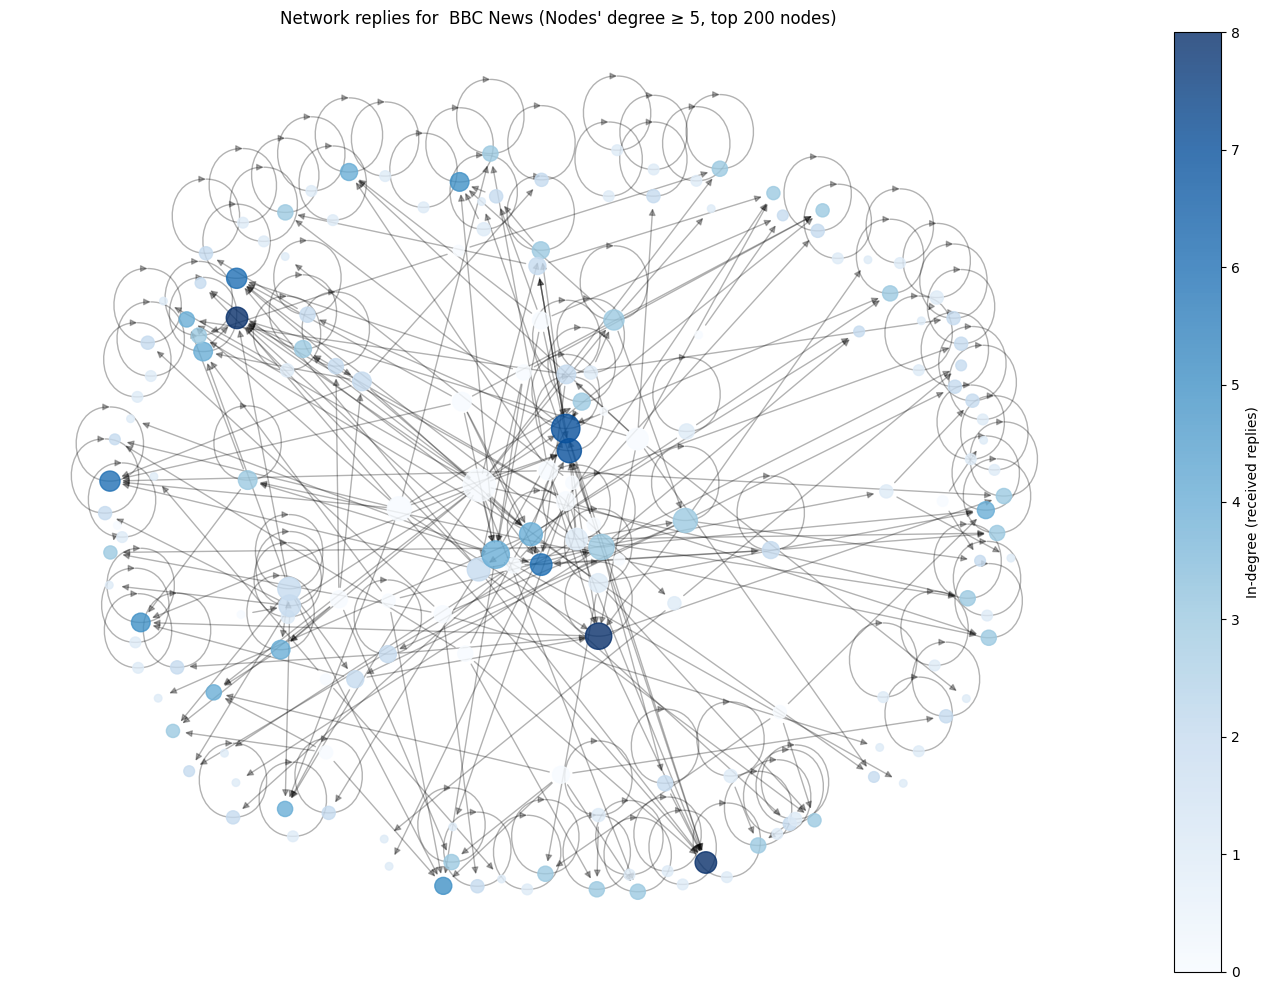

Processing channels:  25%|██▌       | 1/4 [00:03<00:11,  3.70s/it]

Subgraph with 200 nodes and 325 edges

Metrics for CNN:
Nodes (Number of Users): 1089
Edges (Number of Replies): 1067
Average degree (in+out): 1.96
Density: 0.00
Connected components (undirected): 185
Average in-degree centrality (receveid replies): 0.98
Average out- degree centrality (sent replies): 0.98


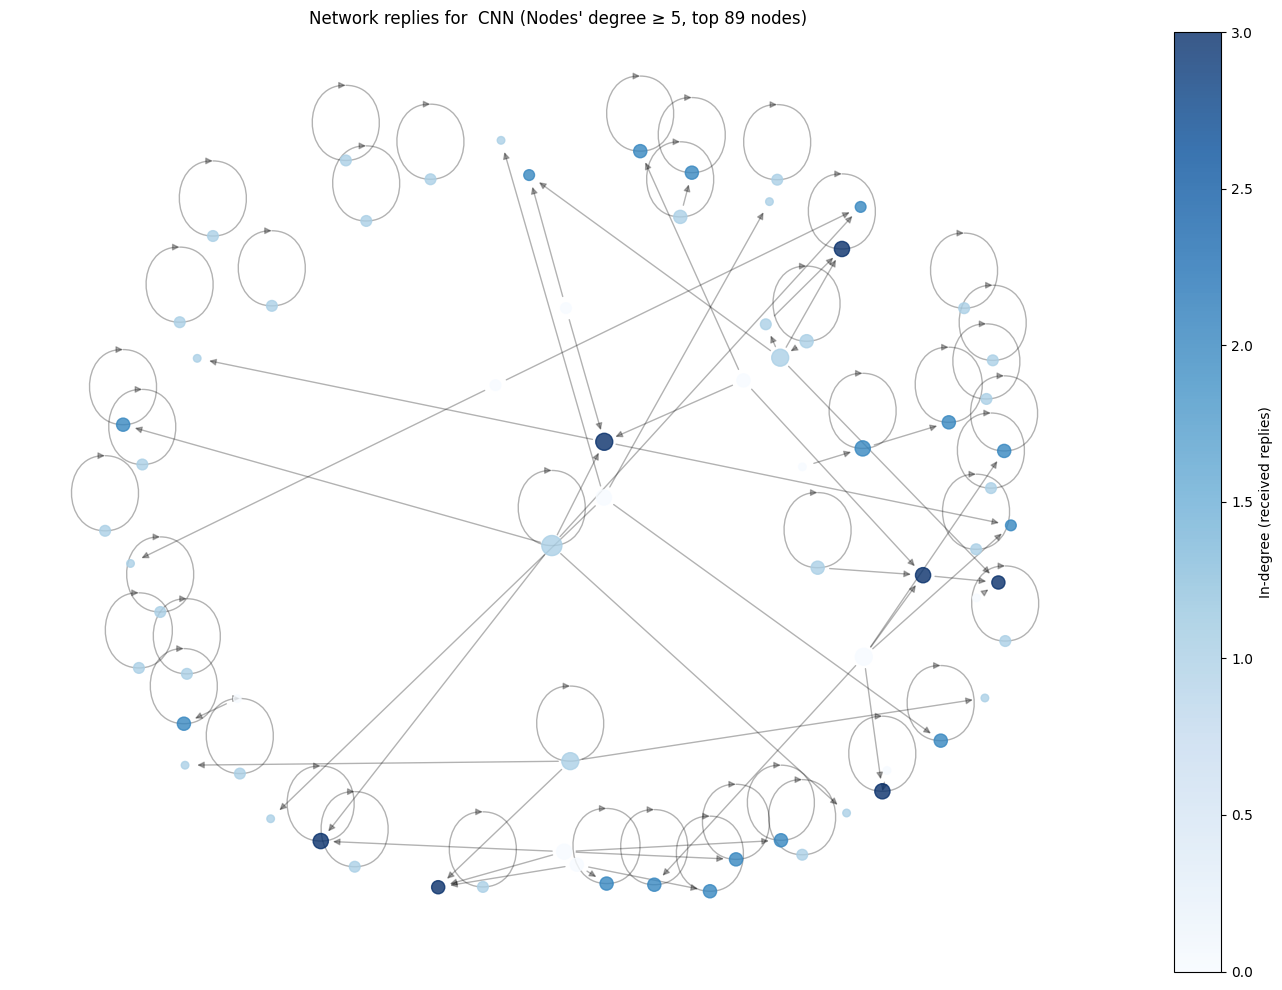

Processing channels:  50%|█████     | 2/4 [00:04<00:04,  2.01s/it]

Subgraph with 89 nodes and 90 edges

Metrics for The Jimmy Dore Show:
Nodes (Number of Users): 1534
Edges (Number of Replies): 1616
Average degree (in+out): 2.11
Density: 0.00
Connected components (undirected): 159
Average in-degree centrality (receveid replies): 1.05
Average out- degree centrality (sent replies): 1.05


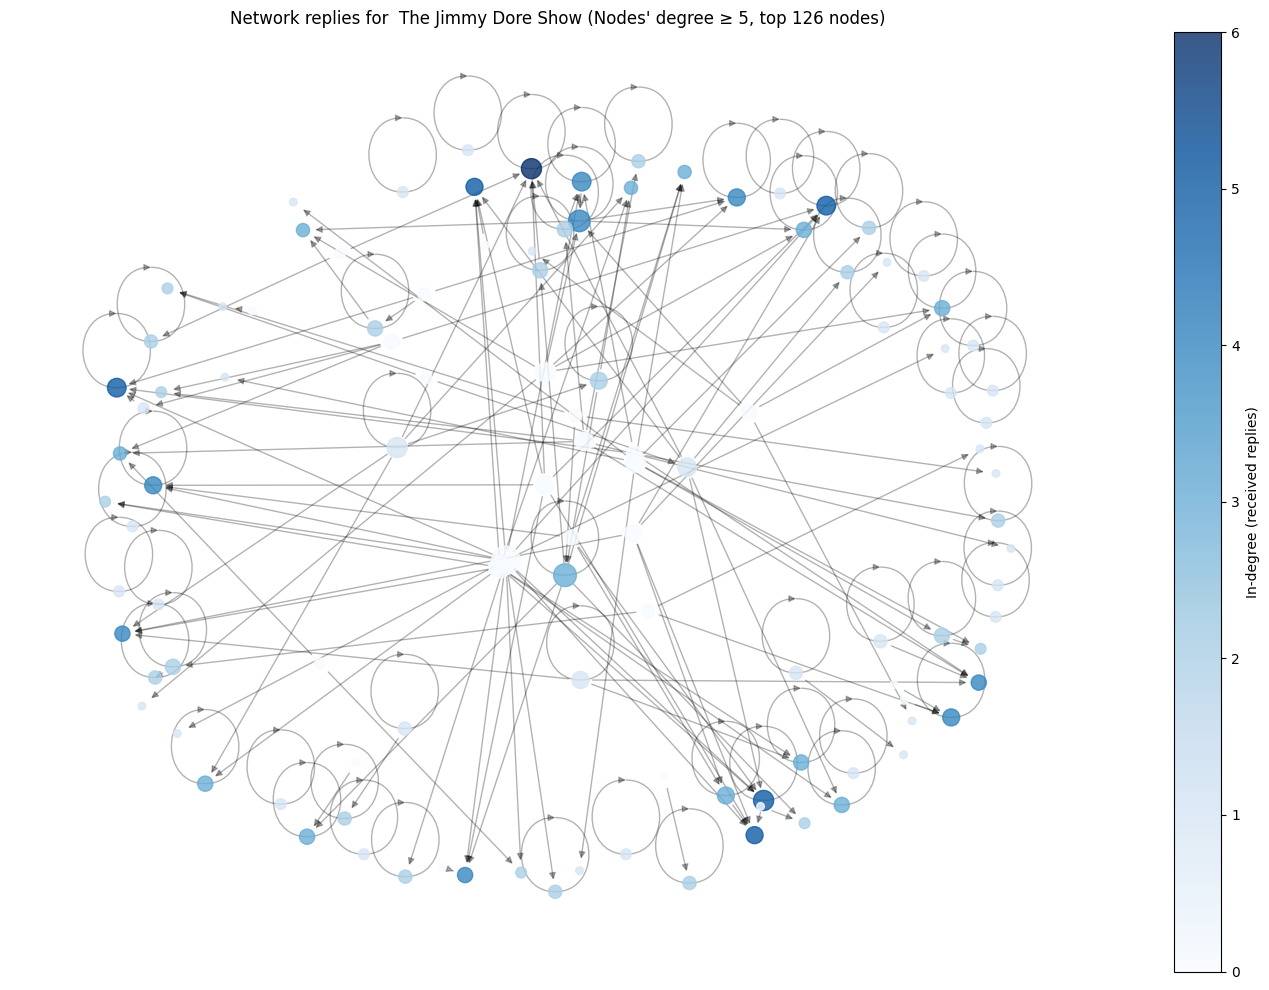

Processing channels:  75%|███████▌  | 3/4 [00:05<00:01,  1.69s/it]

Subgraph with 126 nodes and 182 edges

Metrics for The Young Turks:
Nodes (Number of Users): 1801
Edges (Number of Replies): 1703
Average degree (in+out): 1.89
Density: 0.00
Connected components (undirected): 322
Average in-degree centrality (receveid replies): 0.95
Average out- degree centrality (sent replies): 0.95


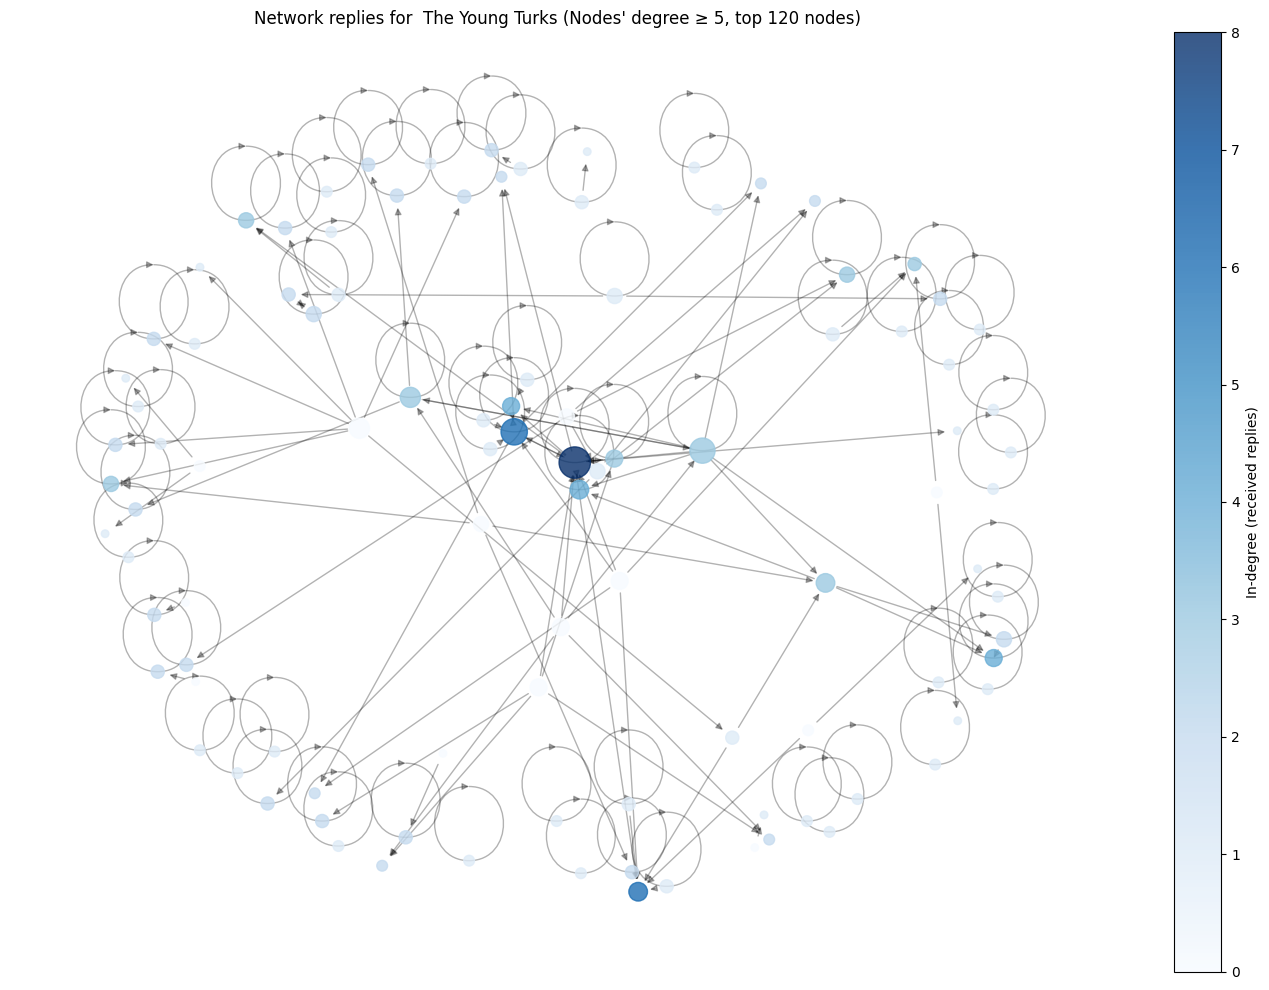

Processing channels: 100%|██████████| 4/4 [00:07<00:00,  1.75s/it]

Subgraph with 120 nodes and 155 edges


In [15]:
# Group by channel
channels = replies_df['channel_id'].unique()  # ['BBC News', 'CNN', 'The Young Turks', 'The Jimmy Dore Show']

# Defining a function for creating a graph per channel
def build_network_for_channel(channel_df):
    G = nx.DiGraph()  # Directed graph (we want to map replies -> comments)

    # Nodes (all users: comment_authors + reply_authors)
    all_users = set(channel_df['reply_author'].dropna()) | set(channel_df['comment_author'].dropna())
    G.add_nodes_from(all_users)

    # If reply exists we add an edge
    for _, row in channel_df.iterrows():
        if pd.notna(row['reply_author']) and pd.notna(row['comment_author']):
            G.add_edge(row['reply_author'], row['comment_author'], reply_id=row['reply_id'], likes=row['reply_likes'])

    return G

# Defining a functions for computing metrics
def compute_metrics(G, channel_name):
    metrics = {
        'Nodes (Number of Users)': G.number_of_nodes(),
        'Edges (Number of Replies)': G.number_of_edges(),
        'Average degree (in+out)': sum(dict(G.degree()).values()) / G.number_of_nodes() if G.number_of_nodes() > 0 else 0,
        'Density': nx.density(G),
        'Connected components (undirected)': nx.number_weakly_connected_components(G),
        'Average in-degree centrality (receveid replies)': sum(dict(G.in_degree()).values()) / G.number_of_nodes() if G.number_of_nodes() > 0 else 0,
        'Average out- degree centrality (sent replies)': sum(dict(G.out_degree()).values()) / G.number_of_nodes() if G.number_of_nodes() > 0 else 0,
    }
    print(f"\nMetrics for {channel_name}:")
    for k, v in metrics.items():
        print(f"{k}: {v:.2f}" if isinstance(v, float) else f"{k}: {v}")
    return metrics

def visualize_network(G, channel_name, min_degree=5, max_nodes=200):
    if G.number_of_nodes() == 0:
        print(f"{channel_name}: Empty graph")
        return

    # Create subgraph only for highly active nodes
    high_degree_nodes = [n for n, d in G.degree() if d >= min_degree]
    if len(high_degree_nodes) > max_nodes:
        high_degree_nodes = sorted(high_degree_nodes, key=lambda n: G.degree(n), reverse=True)[:max_nodes]

    if len(high_degree_nodes) == 0:
        print(f"{channel_name}: No nodes with degree >= {min_degree}")
        return

    G_sub = G.subgraph(high_degree_nodes)

    plt.figure(figsize=(14, 10))
    pos = nx.spring_layout(G_sub, seed=42, k=0.15)

    # Node size proportional to its degree; multiplied by thirty for visibility
    node_sizes = [G_sub.degree(n) * 30 for n in G_sub.nodes()]

    # Colour intensity: in-degree
    in_degrees = dict(G_sub.in_degree())
    node_colors = [in_degrees.get(n, 0) for n in G_sub.nodes()]

    nodes = nx.draw_networkx_nodes(G_sub, pos, node_size=node_sizes, node_color=node_colors,
                           cmap=plt.cm.Blues, alpha=0.8)
    nx.draw_networkx_edges(G_sub, pos, alpha=0.3, arrowsize=10)

    plt.title(f"Network replies for  {channel_name} (Nodes' degree \u2265 {min_degree}, top {len(G_sub)} nodes)")
    # Pass the nodes object to colorbar
    if nodes:
        plt.colorbar(nodes, label='In-degree (received replies)')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    print(f"Subgraph with {len(G_sub)} nodes and {G_sub.number_of_edges()} edges")

# Apply
for channel in tqdm(channels, desc="Processing channels"):
    channel_df = replies_df[replies_df['channel_id'] == channel]
    G = build_network_for_channel(channel_df)
    metrics = compute_metrics(G, channel)
    visualize_network(G, channel)